In [2]:
import matplotlib
#matplotlib.use('Agg')  # Force non-interactive backend
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path

In [3]:
FOLDER_NAME_MAPPING = {
    'MANX_LLM_anitamistral': 'Anita 24B (Uncensored)',
    'MANX_LLM_DeepSeekLarge': 'DeepSeek Chat',
    'MANX_LLM_granite4h': 'Granite 4 Tiny',  
    'MANX_LLM_Grok41FastReasoning': 'Grok 4.1 Fast (Reasoning)',
    'MANX_LLM_magistralsmall': 'Magistral Small',
    'MANX_LLM_ministral3b': 'Ministral 3B',
    'MANX_LLM_ministral14b': 'Ministral 14B (Reasoning)',
    'MANX_LLM_mistralsmall': 'Mistral Small 3.2',
    'MANX_LLM_MistralSmall4': 'Mistral Small 4',
    'MANX_LLM_phi4reasoning': 'Phi-4 (Reasoning+)',
    'MANX_LLM_qwen4bthink': 'Qwen3 4B (Thinking)',
    'MANX_LLM_qwen4bunce': 'Qwen3 4B (Uncensored)',
    'MANX_LLM_qwen34binstruct': 'Qwen3 4B',
    'MANX_LLM_qwen35_9b': 'Qwen3.5 9B'
}

In [4]:
aggregated_file = pd.read_csv("./aggregated/NEW_aggregated_final_wide_format_dataset.csv")

In [5]:
aggregated_file["model_name"] = aggregated_file["model_name"].replace(FOLDER_NAME_MAPPING)

In [6]:
aggregated_file.head()

,run_id,cue_word,valence_cue_word,association_1,association_2,association_3,valence_association_1,valence_association_2,valence_association_3,model_name
0,379a6b95de,ai,0.0,artificial,intelligence,technology,-1,1.0,0.0,Mistral Small 4
1,379a6b95de,algorithm,0.0,code,computation,logic,0,0.0,0.0,Mistral Small 4
2,379a6b95de,anxiety,-1.0,stress,fear,worry,-1,-1.0,-1.0,Mistral Small 4
3,379a6b95de,art,1.0,creativity,paint,expression,1,0.0,0.0,Mistral Small 4
4,379a6b95de,biology,1.0,life,cell,evolution,1,0.0,0.0,Mistral Small 4


In [7]:
filtered = aggregated_file["cue_word"]=="mathematic"
filtered_dataset = aggregated_file[filtered]
new_data=filtered_dataset.groupby(["model_name", "cue_word"])

In [8]:
proportions = new_data.value_counts(normalize=True)
proportions

model_name              cue_word    run_id      valence_cue_word  association_1  association_2  association_3  valence_association_1  valence_association_2  valence_association_3
Anita 24B (Uncensored)  mathematic  fb00b5e5c3  -1.0              number         formula        theory         -1                     -1.0                   -1.0                     0.001605
                                    365a77542c  -1.0              number         formula        geometry       -1                     -1.0                   -1.0                     0.001605
                                    16883fa32c   0.0              number         formula        theory         -1                     -1.0                    0.0                     0.001605
                                    16da7ded60   0.0              number         formula        logic          -1                      0.0                    0.0                     0.001605
                                    e4fb70bb81  -1.0     

In [9]:
# 3. Calculate the overall proportions (multiplying by 100 for percentages)
overall_proportions = filtered_dataset['valence_cue_word'].value_counts(normalize=True) * 100

print("--- Overall Proportions ---")
print(overall_proportions)

# 4. Calculate proportions per individual model
model_proportions = filtered_dataset.groupby('model_name')['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

print("\n--- Proportions by Model ---")
print(model_proportions)

--- Overall Proportions ---
valence_cue_word
 0.0    56.497034
-1.0    24.065471
 1.0    19.437496
Name: proportion, dtype: float64

--- Proportions by Model ---
valence_cue_word                -1.0        0.0        1.0
model_name                                                
Anita 24B (Uncensored)     51.901902  45.295295   2.802803
DeepSeek Chat              36.200000  43.850000  19.950000
Granite 4 Tiny              9.109210  48.766985  42.123805
Grok 4.1 Fast (Reasoning)  40.600000  35.150000  24.250000
Magistral Small            40.050000  54.350000   5.600000
Ministral 14B (Reasoning)  40.050000  40.850000  19.100000
Ministral 3B               13.713714  51.051051  35.235235
Mistral Small 3.2          35.900000  55.700000   8.400000
Mistral Small 4            36.550000  57.050000   6.400000
Phi-4 (Reasoning+)          1.900950  40.270135  57.828914
Qwen3 4B                    3.550000  91.950000   4.500000
Qwen3 4B (Thinking)         1.900000  80.250000  17.850000
Qwen3 4B (Un

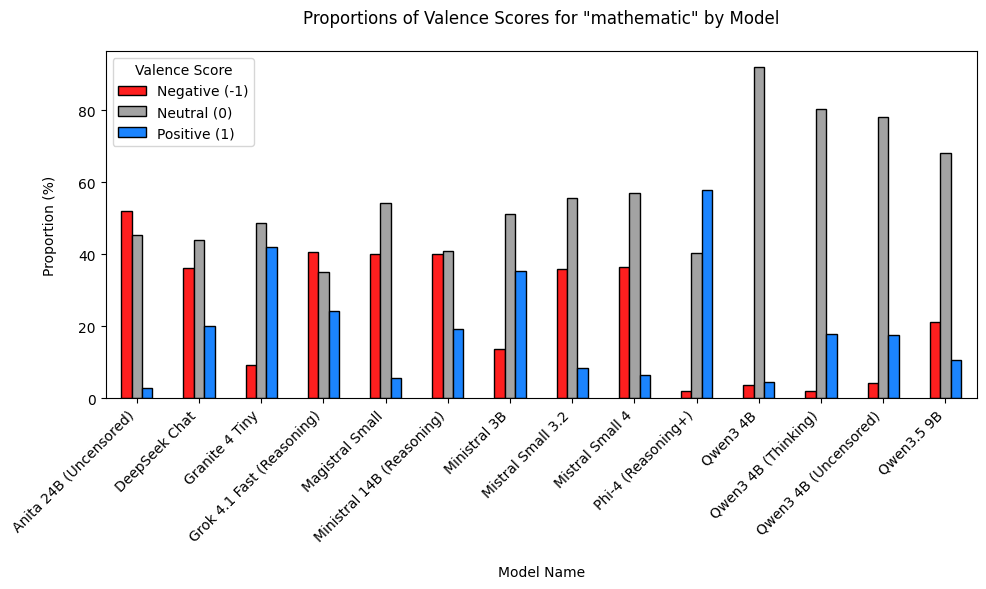

In [10]:
# 3. Calculate proportions per individual model
# unstack(fill_value=0) creates a nice grid, and * 100 converts to percentages
model_proportions = filtered_dataset.groupby('model_name')['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Sort the index (models) alphabetically so the bars are in a reliable sorted order
model_proportions = model_proportions.sort_index()

# 4. Generate the bar plot
# We use pandas built-in plotting, passing color hex codes for Negative, Neutral, and Positive
ax = model_proportions.plot(
    kind='bar', 
    figsize=(10, 6), 
    color = ['#fe1f1f', '#a3a3a3', '#1b84fe'], 
    edgecolor='black'
)

# 5. Format the plot ensuring labels are readable
plt.title('Proportions of Valence Scores for "mathematic" by Model', pad=20)
plt.xlabel('Model Name', labelpad=15)
plt.ylabel('Proportion (%)', labelpad=15)

# Rotate x-axis labels by 45 degrees so the long model names don't overlap
plt.xticks(rotation=45, ha='right')

# Add a descriptive legend
plt.legend(title='Valence Score', labels=['Negative (-1)', 'Neutral (0)', 'Positive (1)'])

# tight_layout() ensures everything fits without getting cropped
plt.tight_layout()
plt.show()

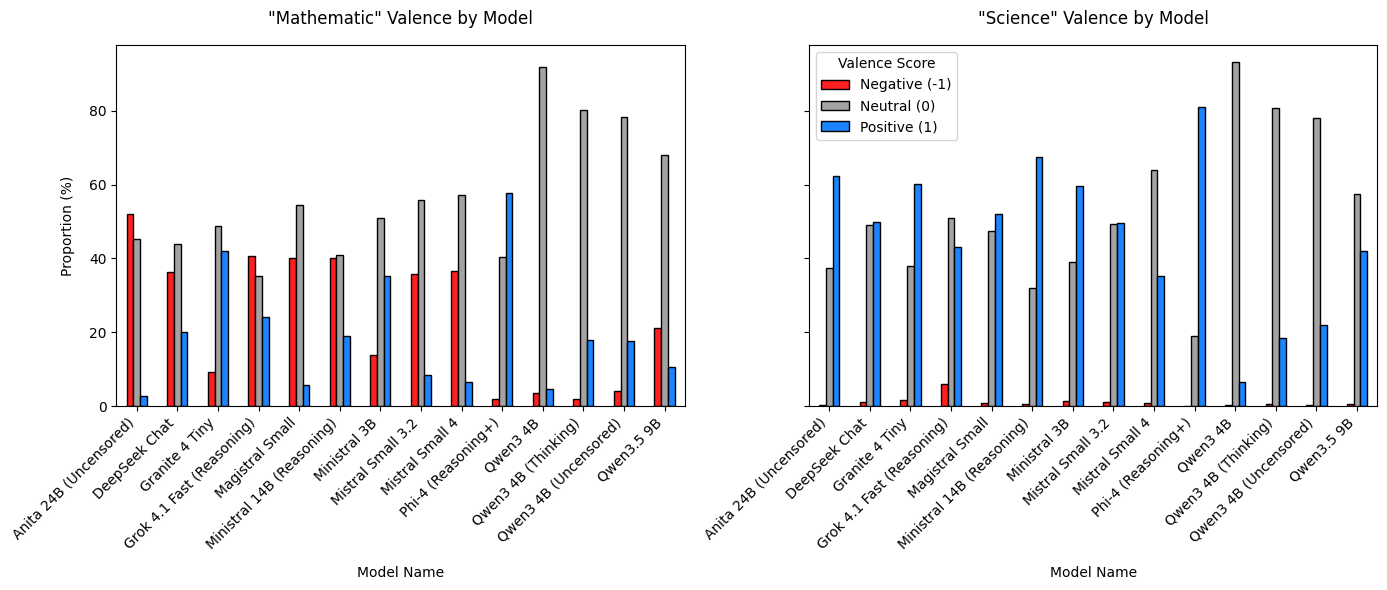

In [11]:
# 1. Load the dataset
df = aggregated_file

# 2. Filter for the cue words
target_words = ['mathematic', 'science']
filtered_df = df[df['cue_word'].isin(target_words)]

# 3. Calculate proportions grouped by BOTH model name and cue word
# unstack() shapes it so valences (-1, 0, 1) are columns
proportions = filtered_df.groupby(['model_name', 'cue_word'])['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Create subplots: 1 row, 2 columns sharing the Y-axis
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

colors = ['#fe1f1f', '#a3a3a3', '#1b84fe']
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 5. Loop through the words and plot them side by side
for i, word in enumerate(target_words):
    # Extract data just for the current word
    word_data = proportions.xs(word, level='cue_word')
    
    # Plot on the corresponding axes (axes[0] for math, axes[1] for science)
    word_data.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', legend=False)
    
    # Formatting
    axes[i].set_title(f'"{word.capitalize()}" Valence by Model', pad=15)
    axes[i].set_xlabel('Model Name', labelpad=10)
    
    # Clean up x-axis labels so they don't overlap
    axes[i].set_xticklabels(word_data.index, rotation=45, ha='right')

# Set the y-label only on the first (left) subplot
axes[0].set_ylabel('Proportion (%)', labelpad=10)

# Add the legend to the second (right) subplot
axes[1].legend(title='Valence Score', labels=labels, loc='upper left')

# 6. Adjust layout to prevent labels from getting cut off and save
plt.tight_layout()
plt.savefig("./visualizations/Keywords_valence_comparison.svg", dpi=300,format="svg")
plt.show()

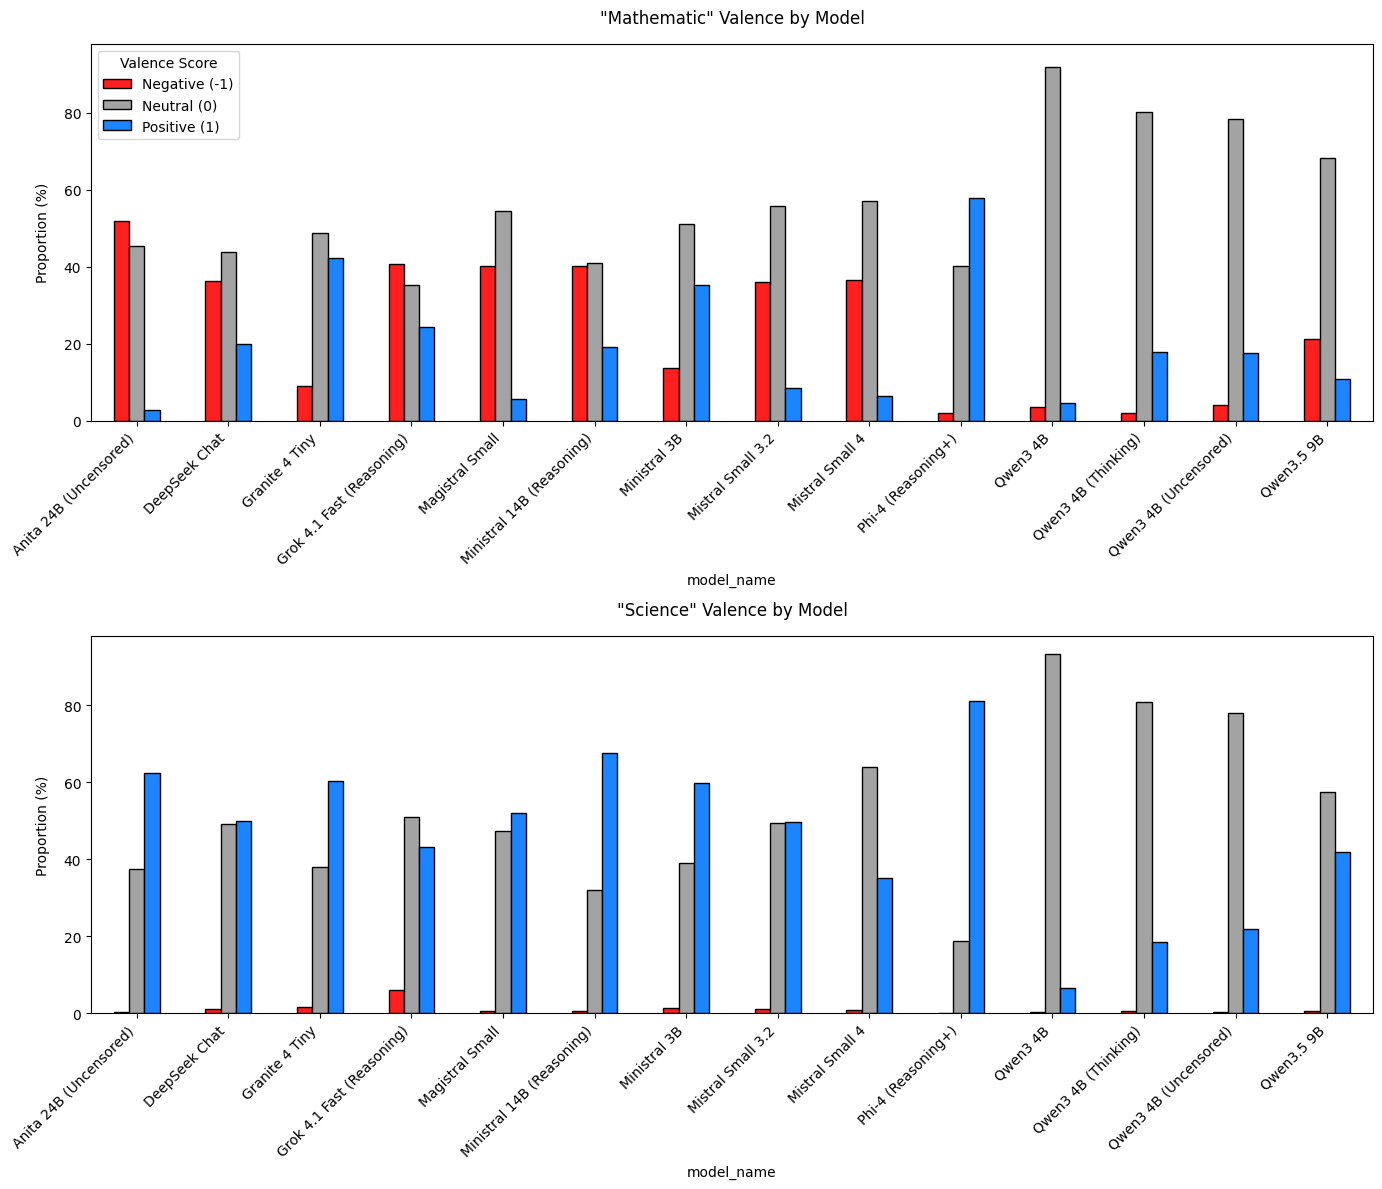

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = aggregated_file

# 2. Filter for the cue words
target_words = ['mathematic', 'science']
filtered_df = df[df['cue_word'].isin(target_words)]

# 3. Calculate proportions grouped by BOTH model name and cue word
# unstack() shapes it so valences (-1, 0, 1) are columns
proportions = filtered_df.groupby(['model_name', 'cue_word'])['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Create subplots: 2 rows, 1 column 
# Adjusted figsize to be taller (14, 12) and optionally shared the X-axis
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharey=True)

colors = ['#fe1f1f', '#a3a3a3', '#1b84fe']
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 5. Loop through the words and plot them stacked vertically
for i, word in enumerate(target_words):
    # Extract data just for the current word
    word_data = proportions.xs(word, level='cue_word')
    
    # Plot on the corresponding axes (axes[0] is top, axes[1] is bottom)
    word_data.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', legend=False)
    
    # Formatting
    axes[i].set_title(f'"{word.capitalize()}" Valence by Model', pad=15)
    
    # Set the y-label on BOTH subplots since they are stacked vertically now
    axes[i].set_ylabel('Proportion (%)', labelpad=10)
    
    # Clean up x-axis labels so they don't overlap
    axes[i].set_xticklabels(word_data.index, rotation=45, ha='right')

# Set the x-label only on the bottom subplot
#axes[1].set_xlabel('Model Name', labelpad=10)

# Add the legend to the top subplot (axes[0]) so it's clearly visible
axes[0].legend(title='Valence Score', labels=labels, loc='upper left')

# 6. Adjust layout to prevent labels from getting cut off and display
plt.tight_layout()
plt.savefig("./visualizations/Keywords_valence_comparison_horizontal.svg", dpi=300,format="svg")
plt.show()

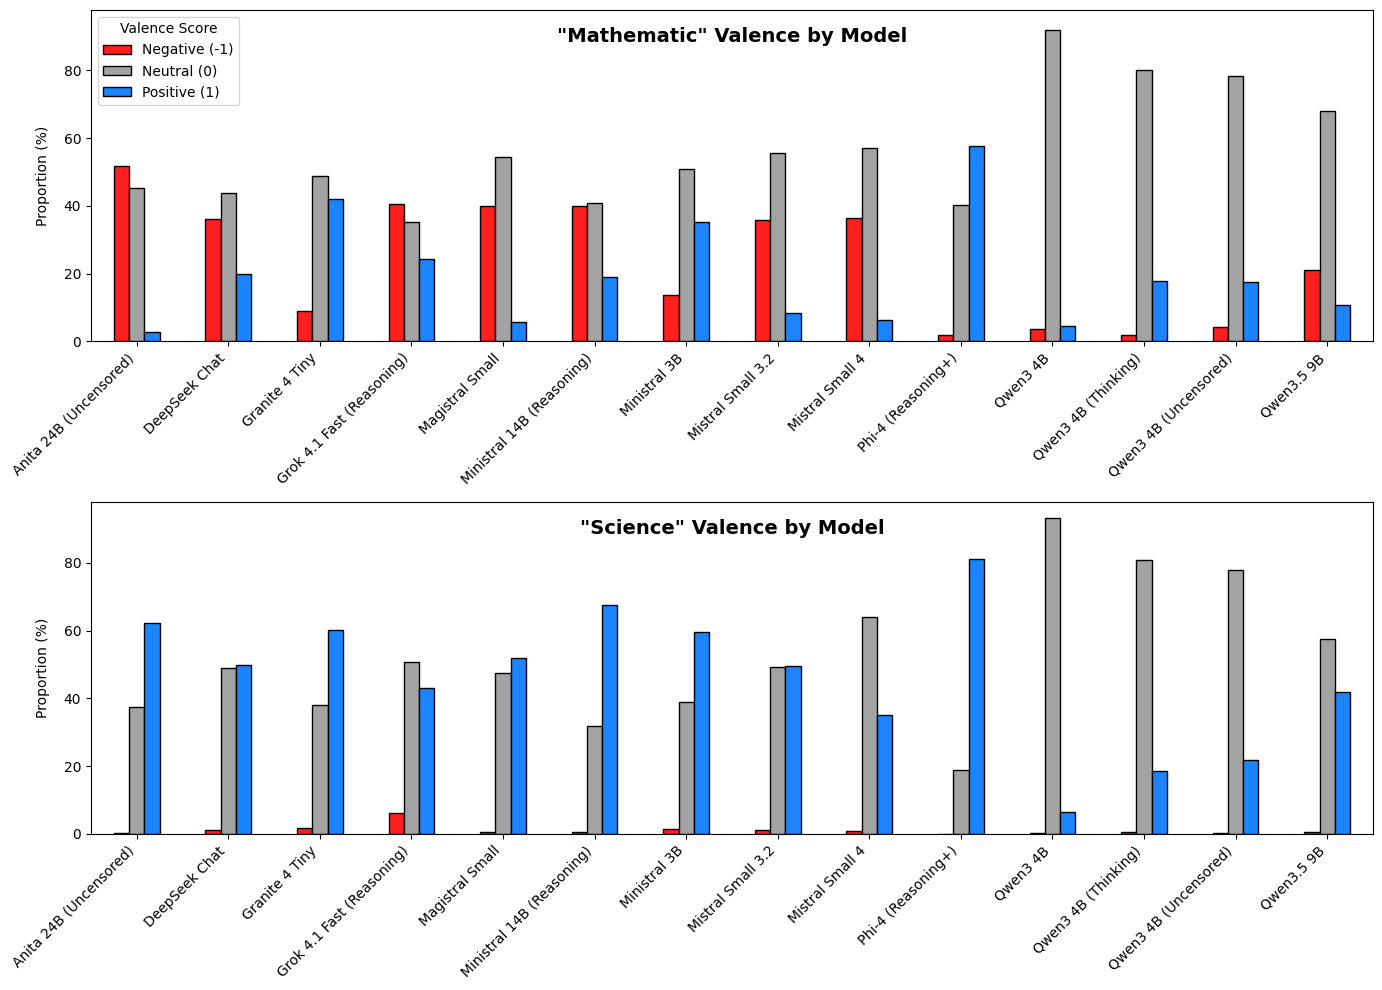

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
# df = aggregated_file

# 2. Filter for the cue words
target_words = ['mathematic', 'science']
filtered_df = df[df['cue_word'].isin(target_words)]

# 3. Calculate proportions grouped by BOTH model name and cue word
# unstack() shapes it so valences (-1, 0, 1) are columns
proportions = filtered_df.groupby(['model_name', 'cue_word'])['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Create subplots: 2 rows, 1 column 
# Slightly adjusted figsize for better proportions
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

colors = ['#fe1f1f', '#a3a3a3', '#1b84fe']
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 5. Loop through the words and plot them stacked vertically
for i, word in enumerate(target_words):
    # Extract data just for the current word
    word_data = proportions.xs(word, level='cue_word')
    
    # Plot on the corresponding axes (axes[0] is top, axes[1] is bottom)
    word_data.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', legend=False)
    
    # --- MODIFICATION 1: Title inside the plot ---
    # Centered horizontally (0.5) so it doesn't overlap with the left-aligned legend
    axes[i].text(0.5, 0.95, f'"{word.capitalize()}" Valence by Model', 
                 transform=axes[i].transAxes, 
                 fontsize=14, 
                 fontweight='bold',
                 va='top', 
                 ha='center',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
    
    # Set the y-label
    axes[i].set_ylabel('Proportion (%)', labelpad=10)
    
    # --- MODIFICATION 2: Keep model names, remove "model_name" label ---
    axes[i].set_xlabel('') # This removes the generic "model_name" label
    axes[i].set_xticklabels(word_data.index, rotation=45, ha='right')

# --- MODIFICATION 3: Legend to the left ---
# Add the legend to the top subplot (axes[0]) on the upper left
axes[0].legend(title='Valence Score', labels=labels, loc='upper left')

# 6. Adjust layout to prevent labels from getting cut off and display
plt.tight_layout()
# plt.savefig("./visualizations/Keywords_valence_comparison_horizontal.svg", dpi=300, format="svg")
plt.show()

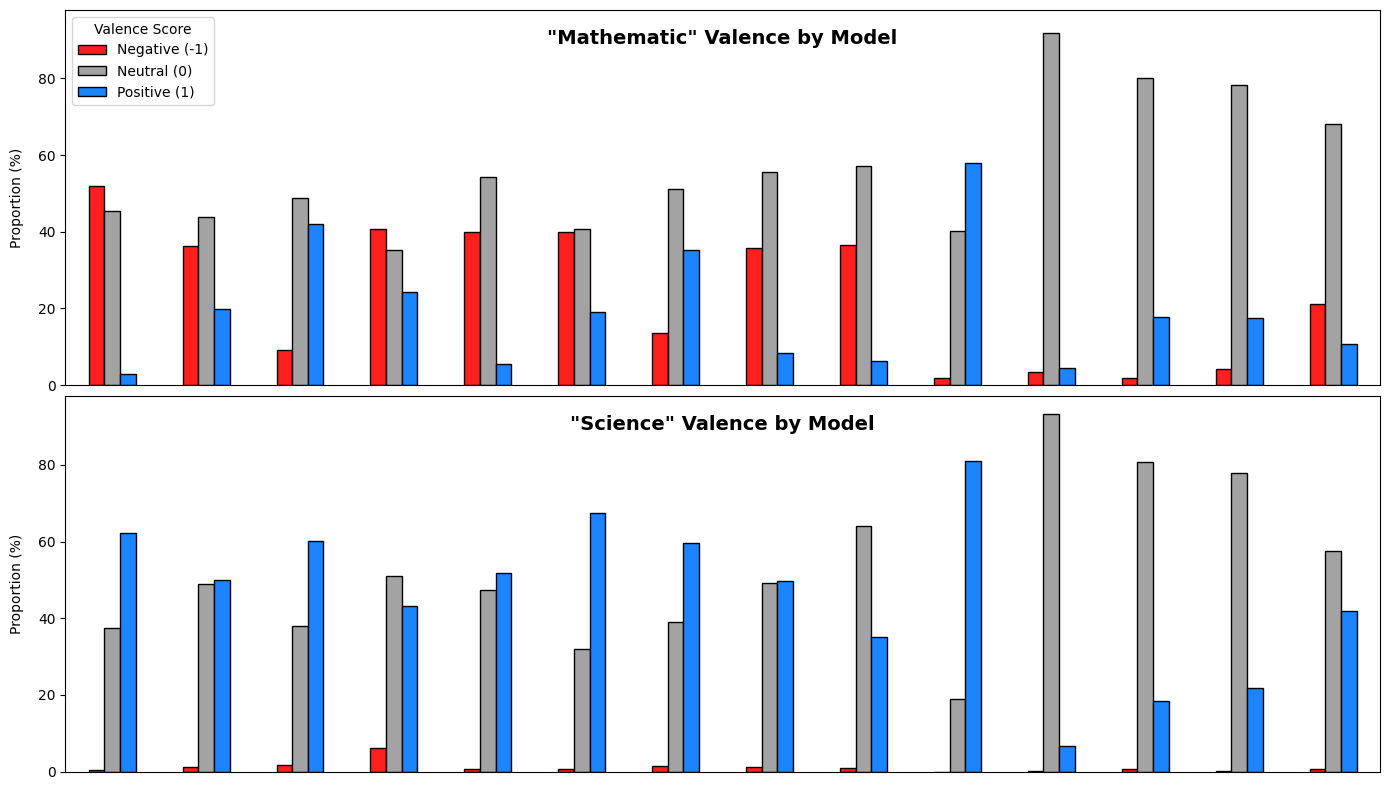

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
# df = aggregated_file

# 2. Filter for the cue words
target_words = ['mathematic', 'science']
filtered_df = df[df['cue_word'].isin(target_words)]

# 3. Calculate proportions grouped by BOTH model name and cue word
proportions = filtered_df.groupby(['model_name', 'cue_word'])['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Create subplots: 2 rows, 1 column 
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharey=True)

colors = ['#fe1f1f', '#a3a3a3', '#1b84fe']
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 5. Loop through the words and plot them stacked vertically
for i, word in enumerate(target_words):
    # Extract data just for the current word
    word_data = proportions.xs(word, level='cue_word')
    
    # Plot on the corresponding axes
    word_data.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', legend=False)
    
    # --- FIXED: Title centered inside the plot ---
    # x=0.5 places it exactly in the middle horizontally
    axes[i].text(0.5, 0.95, f'"{word.capitalize()}" Valence by Model', 
                 transform=axes[i].transAxes, 
                 fontsize=14, 
                 fontweight='bold',
                 va='top', 
                 ha='center', 
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
    
    # Set the y-label
    axes[i].set_ylabel('Proportion (%)', labelpad=10)
    
    # Remove x-axis names to save space
    axes[i].set_xticks([])         
    axes[i].set_xticklabels([])    
    axes[i].set_xlabel('')         

# --- FIXED: Legend in the upper right ---
# Removed bbox_to_anchor so it defaults to the actual upper right corner inside the plot
axes[0].legend(title='Valence Score', labels=labels, loc='upper left')

# 6. Adjust layout
plt.tight_layout(h_pad=0.2)
# plt.savefig("./visualizations/Keywords_valence_comparison_horizontal.svg", dpi=300, format="svg")
plt.show()

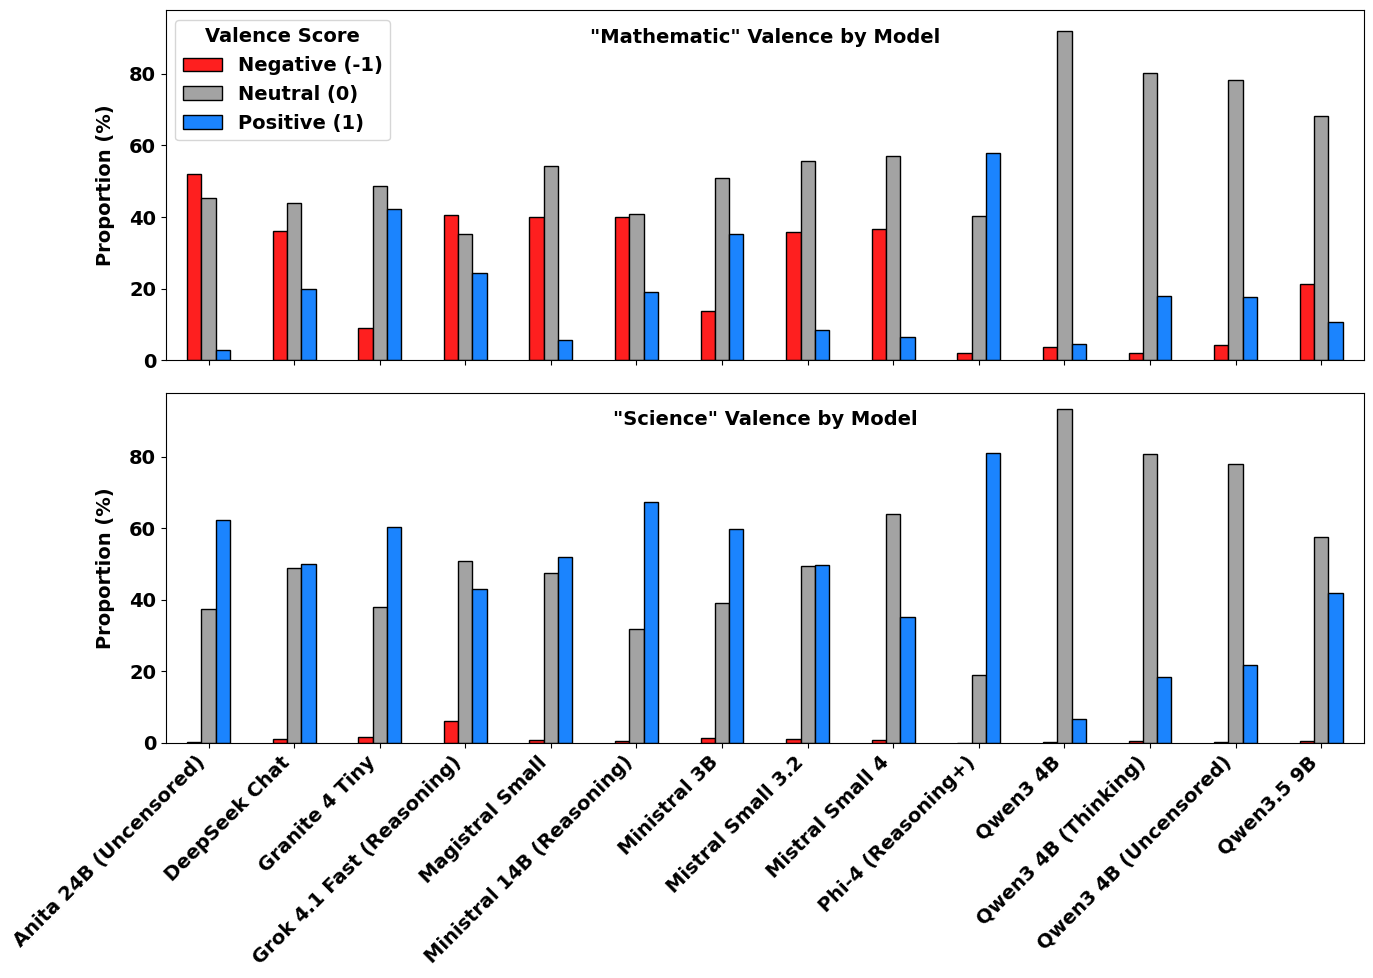

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Set global font properties so all text matches the title's style
plt.rcParams.update({
    'font.size': 14,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

# 1. Load the dataset
# df = aggregated_file

# 2. Filter for the cue words
target_words = ['mathematic', 'science']
filtered_df = df[df['cue_word'].isin(target_words)]

# 3. Calculate proportions grouped by BOTH model name and cue word
# unstack() shapes it so valences (-1, 0, 1) are columns
proportions = filtered_df.groupby(['model_name', 'cue_word'])['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Create subplots: 2 rows, 1 column 
# Slightly adjusted figsize for better proportions
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

colors = ['#fe1f1f', '#a3a3a3', '#1b84fe']
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 5. Loop through the words and plot them stacked vertically
for i, word in enumerate(target_words):
    # Extract data just for the current word
    word_data = proportions.xs(word, level='cue_word')
    
    # Plot on the corresponding axes (axes[0] is top, axes[1] is bottom)
    word_data.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', legend=False)
    
    # --- NEW: Explicitly remove the grid ---
    axes[i].grid(False)
    
    # Title inside the plot 
    # Centered horizontally (0.5) so it doesn't overlap with the left-aligned legend
    axes[i].text(0.5, 0.95, f'"{word.capitalize()}" Valence by Model', 
                 transform=axes[i].transAxes, 
                 fontsize=14, 
                 fontweight='bold',
                 va='top', 
                 ha='center',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
    
    # Set the y-label
    axes[i].set_ylabel('Proportion (%)', labelpad=10)
    
    # Keep model names, remove "model_name" label
    axes[i].set_xlabel('') # This removes the generic "model_name" label
    
    # Conditionally remove x-tick labels for the top row 
    if i == 0:
        axes[i].set_xticklabels([]) # Hides model names on the top subplot
    else:
        axes[i].set_xticklabels(word_data.index, rotation=45, ha='right')

# Legend to the left 
# Add the legend to the top subplot (axes[0]) on the upper left
axes[0].legend(title='Valence Score', labels=labels, loc='upper left')

# 6. Adjust layout to prevent labels from getting cut off and display
plt.tight_layout()
#plt.savefig("./visualizations/Keywords_valence_comparison_horizontal_final.svg", dpi=300, format="svg")
plt.show()

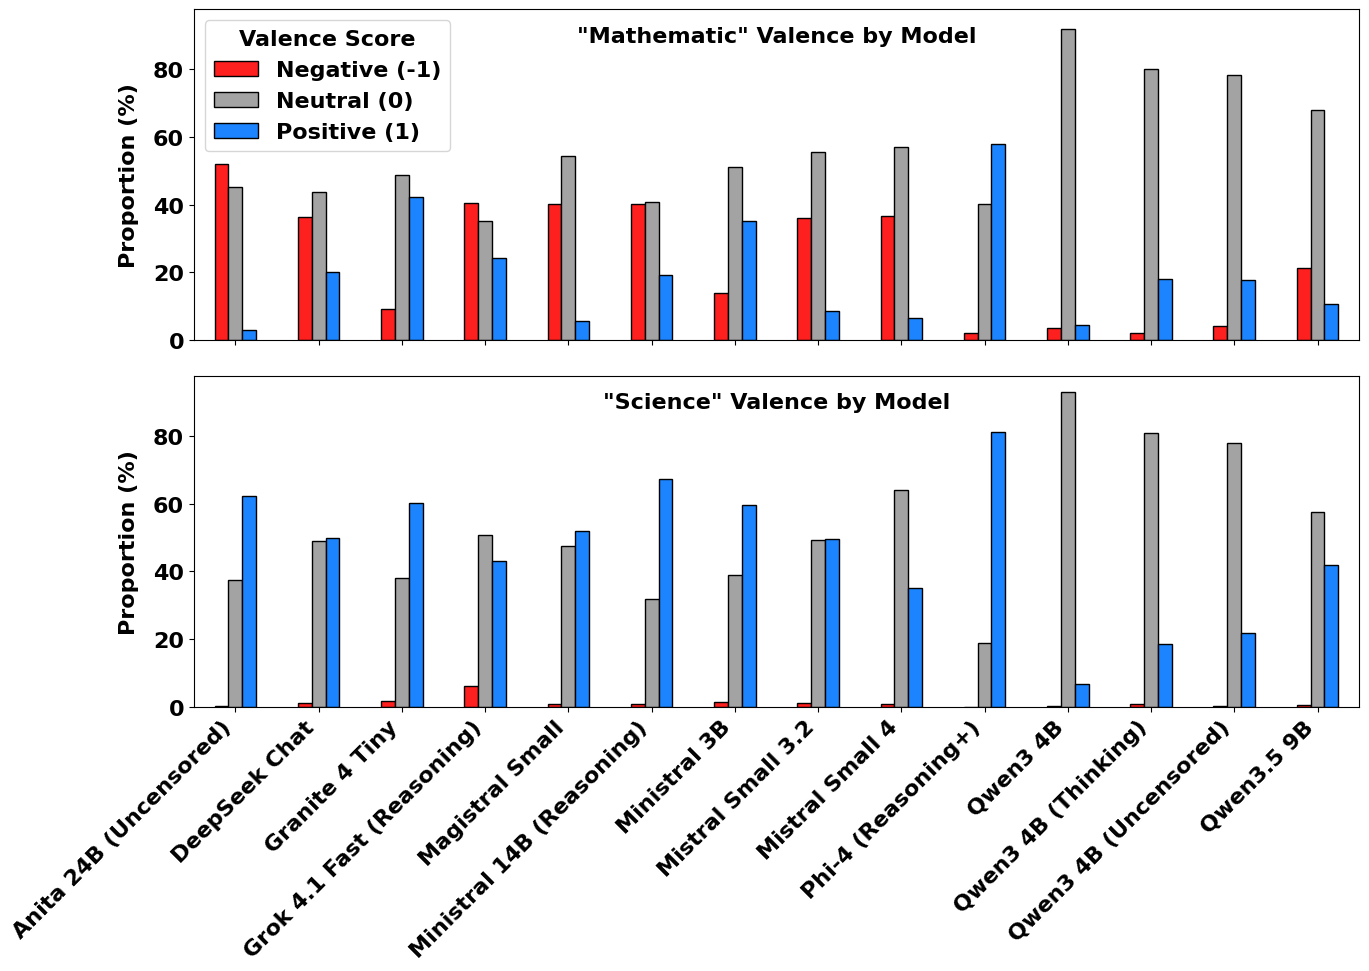

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# --- CHANGED: Expanded global font properties to strictly enforce uniformity ---
plt.rcParams.update({
    'font.family': 'sans-serif',   # Add a specific font like 'Arial' here if needed
    'font.size': 16,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'legend.title_fontsize': 16
})

# 1. Load the dataset
# df = aggregated_file

# 2. Filter for the cue words
target_words = ['mathematic', 'science']
filtered_df = df[df['cue_word'].isin(target_words)]

# 3. Calculate proportions grouped by BOTH model name and cue word
# unstack() shapes it so valences (-1, 0, 1) are columns
proportions = filtered_df.groupby(['model_name', 'cue_word'])['valence_cue_word'].value_counts(normalize=True).unstack(fill_value=0) * 100

# 4. Create subplots: 2 rows, 1 column 
# Slightly adjusted figsize for better proportions
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

colors = ['#fe1f1f', '#a3a3a3', '#1b84fe']
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

# 5. Loop through the words and plot them stacked vertically
for i, word in enumerate(target_words):
    # Extract data just for the current word
    word_data = proportions.xs(word, level='cue_word')
    
    # Plot on the corresponding axes (axes[0] is top, axes[1] is bottom)
    word_data.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black', legend=False)
    
    # Explicitly remove the grid 
    axes[i].grid(False)
    
    # Title inside the plot 
    # Centered horizontally (0.5) so it doesn't overlap with the left-aligned legend
    axes[i].text(0.5, 0.95, f'"{word.capitalize()}" Valence by Model', 
                 transform=axes[i].transAxes, 
                 fontsize=16, 
                 fontweight='bold',
                 va='top', 
                 ha='center',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))
    
    # Set the y-label
    axes[i].set_ylabel('Proportion (%)', labelpad=10)
    
    # Keep model names, remove "model_name" label
    axes[i].set_xlabel('') # This removes the generic "model_name" label
    
    # Conditionally remove x-tick labels for the top row 
    if i == 0:
        axes[i].set_xticklabels([]) # Hides model names on the top subplot
    else:
        # Added fontweight='bold' here to prevent pandas from overriding the rcParams
        axes[i].set_xticklabels(word_data.index, rotation=45, ha='right', fontweight='bold')

    # Force y-ticks to be bold just in case the backend overrides it
    for label in axes[i].get_yticklabels():
        label.set_fontweight('bold')

# Legend to the left 
# Add the legend to the top subplot (axes[0]) on the upper left
# Added prop={'weight': 'bold'} to strictly enforce legend label weight
axes[0].legend(title='Valence Score', labels=labels, loc='upper left', prop={'weight': 'bold'})
# Enforce the legend title weight
axes[0].get_legend().get_title().set_fontweight('bold')

# 6. Adjust layout to prevent labels from getting cut off and display
plt.tight_layout()
plt.savefig("./visualizations/FINAL_Keywords_valence_comparison_horizontal.svg", dpi=300, format="svg")
plt.show()

Plot successfully generated and saved!


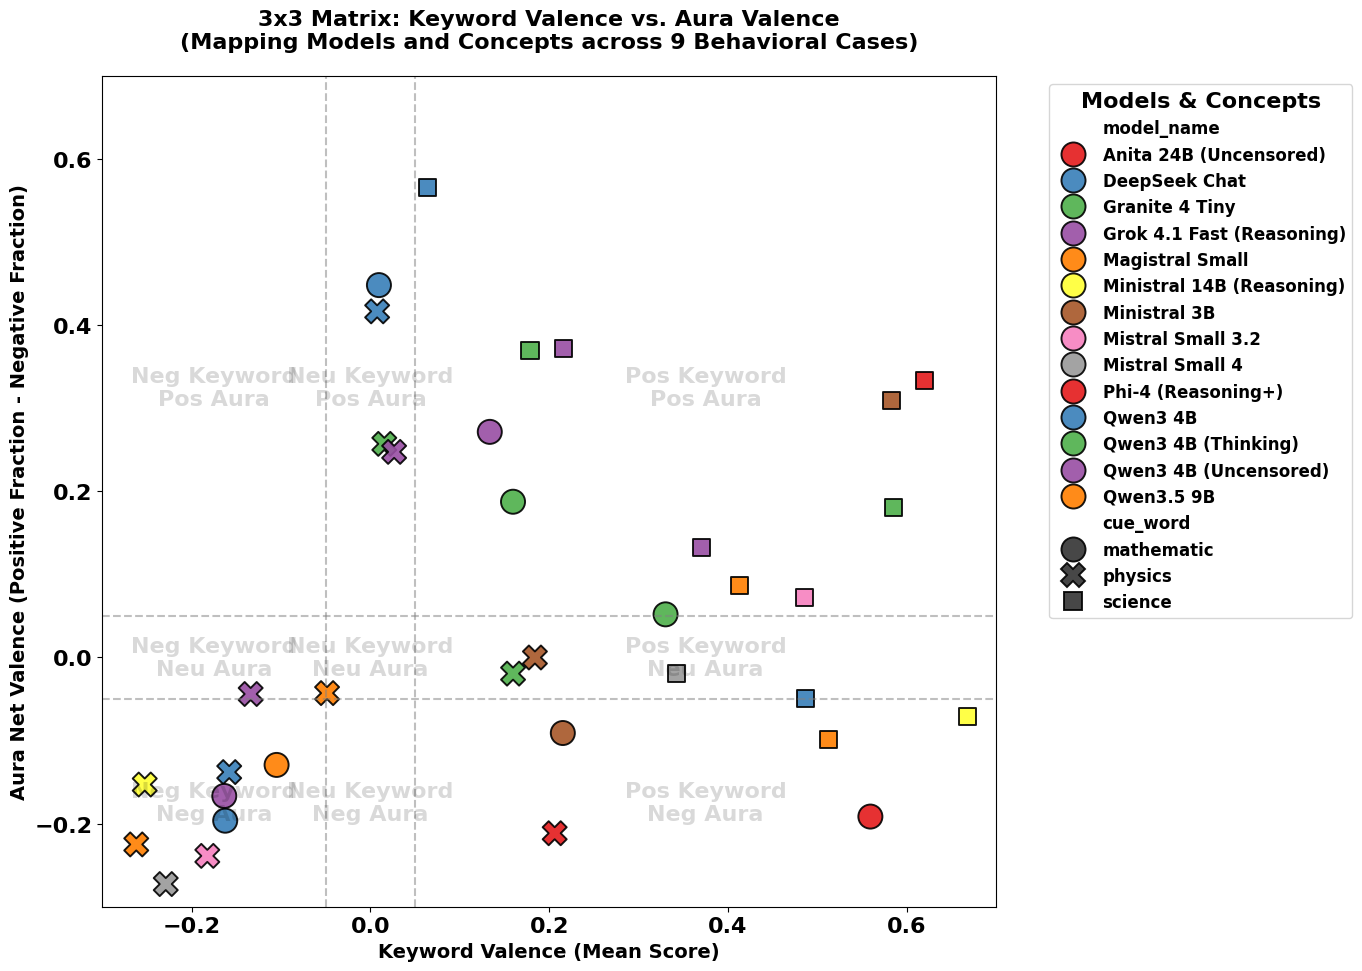

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the datasets
df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/aggregated_aura_valences.csv')


# Clean the model names in the aura dataset to perfectly match the wide dataset
df_aura['model_name'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)

# 2. Calculate the mean Keyword Valence per model and per cue word
agg_wide = df_wide.groupby(['model_name', 'cue_word'])['valence_cue_word'].mean().reset_index()

# 3. Merge the Keyword Valence and Aura Valence datasets
merged = pd.merge(agg_wide, df_aura, on=['model_name', 'cue_word'], how='inner')

# 4. Set up the figure for the 3x3 grid plot
plt.figure(figsize=(14, 10))

# Plot the models and words as a scatterplot
ax = sns.scatterplot(
    data=merged, 
    x='valence_cue_word', 
    y='aura_net_valence', 
    hue='model_name', 
    style='cue_word', 
    s=300, 
    palette='Set1',
    edgecolor='black',
    alpha=0.9
)

# 5. Define thresholds to split into 9 cases (Negative < -0.05, Neutral, Positive > 0.05)
t_neg, t_pos = -0.05, 0.05

# Draw the vertical and horizontal grid lines
plt.axvline(t_neg, color='gray', linestyle='--', alpha=0.5)
plt.axvline(t_pos, color='gray', linestyle='--', alpha=0.5)
plt.axhline(t_neg, color='gray', linestyle='--', alpha=0.5)
plt.axhline(t_pos, color='gray', linestyle='--', alpha=0.5)

# Lock axis limits so the 9 quadrants are clearly visible
ax.set_xlim(-0.3, 0.7)
ax.set_ylim(-0.3, 0.7)

# 6. Annotate the background of the 9 specific cases
regions = {
    'Neg Keyword\nPos Aura': (-0.175, 0.325),
    'Neu Keyword\nPos Aura': (0, 0.325),
    'Pos Keyword\nPos Aura': (0.375, 0.325),
    
    'Neg Keyword\nNeu Aura': (-0.175, 0),
    'Neu Keyword\nNeu Aura': (0, 0),
    'Pos Keyword\nNeu Aura': (0.375, 0),
    
    'Neg Keyword\nNeg Aura': (-0.175, -0.175),
    'Neu Keyword\nNeg Aura': (0, -0.175),
    'Pos Keyword\nNeg Aura': (0.375, -0.175),
}

for text, (x, y) in regions.items():
    # Place large, faded text into the background of each grid section
    plt.text(x, y, text, alpha=0.15, fontsize=16, ha='center', va='center', weight='bold')

# 7. Format labels and legend
plt.title('3x3 Matrix: Keyword Valence vs. Aura Valence\n(Mapping Models and Concepts across 9 Behavioral Cases)', pad=20, fontsize=16)
plt.xlabel('Keyword Valence (Mean Score)', fontsize=14)
plt.ylabel('Aura Net Valence (Positive Fraction - Negative Fraction)', fontsize=14)

# Move legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models & Concepts", fontsize=12)
plt.tight_layout()
plt.savefig("./visualizations/Keywords_Aura_comparison_matrix.svg", dpi=300,format="svg")

# Save the resulting 3x3 plot
#plt.savefig('3x3_valence_comparison.png')
print("Plot successfully generated and saved!")

/var/folders/mr/318qq8ns08140x5d2pm9yxh80000gn/T/ipykernel_4647/1308352397.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
/var/folders/mr/318qq8ns08140x5d2pm9yxh80000gn/T/ipykernel_4647/1308352397.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
/var/folders/mr/318qq8ns08140x5d2pm9yxh80000gn/T/ipykernel_4647/1308352397.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)


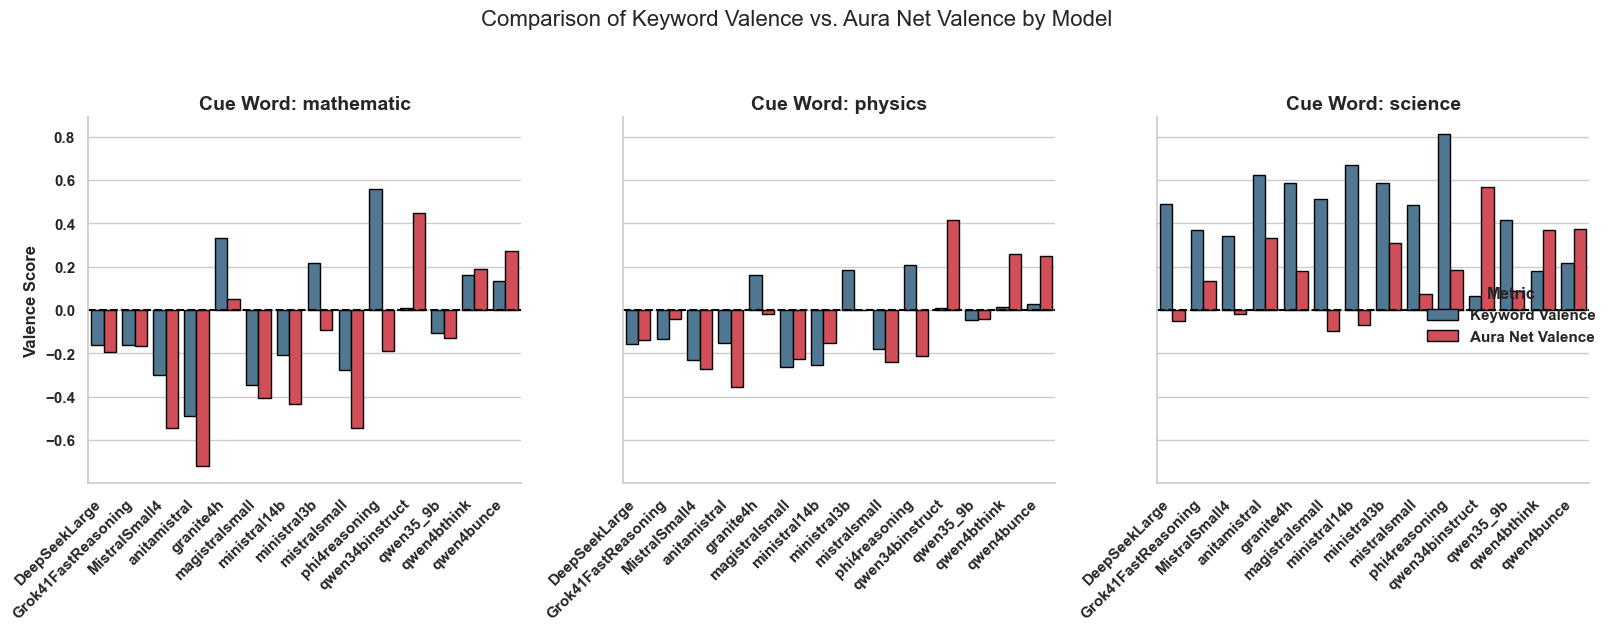

In [18]:
# 1. Load and prepare data
df_wide = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/NEW_aggregated_final_wide_format_dataset.csv')
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/aggregated_aura_valences.csv')
df_aura['model_name'] = df_aura['model_name'].str.replace('compatible_dataset_', '')

# Aggregate the wide dataset to get the mean valence per keyword
agg_wide = df_wide.groupby(['model_name', 'cue_word'])['valence_cue_word'].mean().reset_index()

# Merge both datasets together
merged = pd.merge(agg_wide, df_aura, on=['model_name', 'cue_word'], how='inner')

# 2. Reshape data for seaborn
# 'melt' turns our two columns (keyword valence and aura valence) into rows 
# so we can easily group them side-by-side in a bar chart.
df_melt = pd.melt(
    merged, 
    id_vars=['model_name', 'cue_word'],
    value_vars=['valence_cue_word', 'aura_net_valence'],
    var_name='Metric', 
    value_name='Score'
)

# Clean up names for a prettier legend and x-axis
df_melt['Metric'] = df_melt['Metric'].replace({
    'valence_cue_word': 'Keyword Valence',
    'aura_net_valence': 'Aura Net Valence'
})
df_melt['model_name_short'] = df_melt['model_name'].str.replace('MANX_LLM_', '')

# 3. Create the Plot
sns.set_theme(style="whitegrid")

# catplot creates a facet grid (subplots) based on the 'col' parameter
g = sns.catplot(
    data=df_melt, 
    kind="bar",
    x="model_name_short", 
    y="Score", 
    hue="Metric",
    col="cue_word",     # Creates one subplot per cue word
    col_wrap=3,         # Puts them in a row of 3
    palette=["#457b9d", "#e63946"], # Blue for Keyword, Red for Aura
    height=6, 
    aspect=0.8,
    edgecolor="black"
)

# 4. Format the plot
g.set_axis_labels("", "Valence Score")
g.set_titles(col_template="Cue Word: {col_name}", size=14)

# Add a zero-line across all charts so positive/negative splits are obvious
for ax in g.axes.flat:
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    # Rotate the model names so they don't overlap
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)

plt.suptitle("Comparison of Keyword Valence vs. Aura Net Valence by Model", y=1.05, fontsize=16)

# Prevent labels from being cut off
plt.tight_layout()


# Save the figure
#plt.savefig('paired_barplot_comparison.png', dpi=300, bbox_inches='tight')

Plot successfully generated and saved!


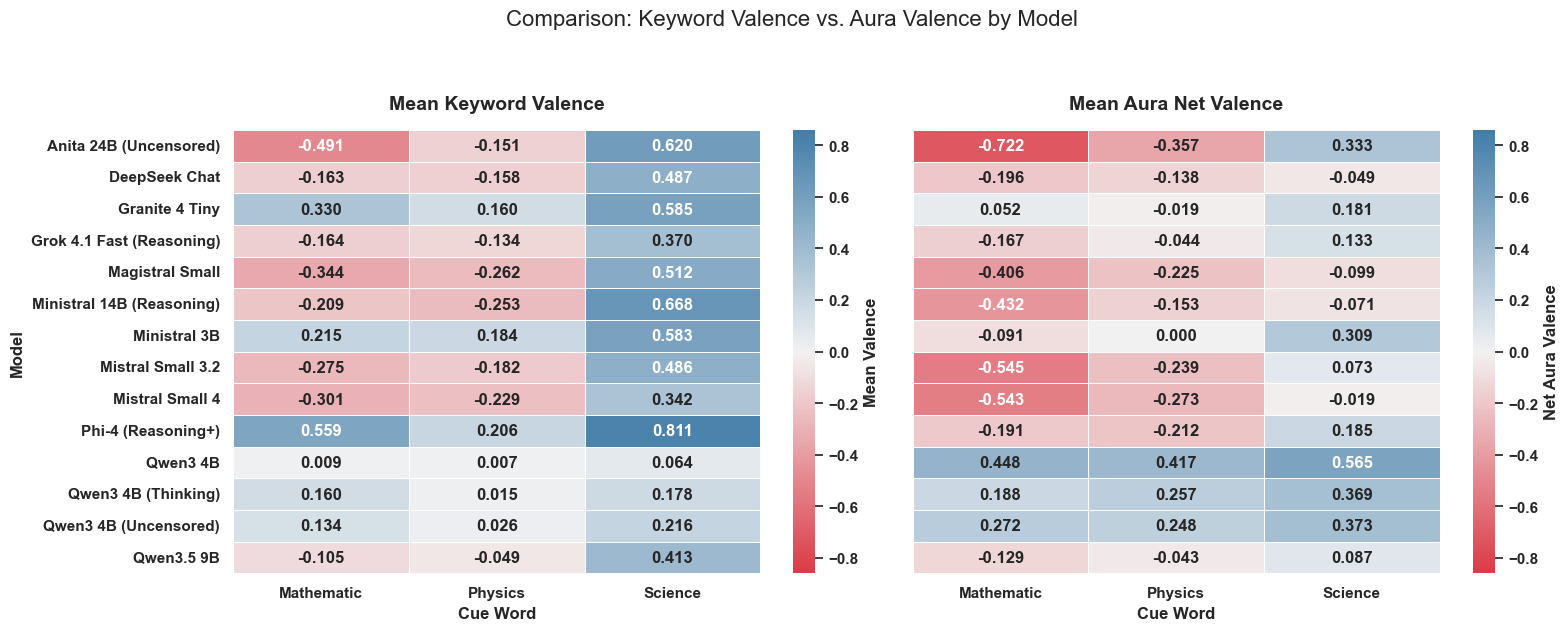

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the datasets
df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/aggregated_aura_valences.csv')

# Clean up model names in the aura dataset to match the wide dataset
df_aura['model_name'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)

# 2. Calculate the mean keyword valence per model and cue word
agg_wide = df_wide.groupby(['model_name', 'cue_word'])['valence_cue_word'].mean().reset_index()

# 3. Merge the two datasets together
merged = pd.merge(agg_wide, df_aura, on=['model_name', 'cue_word'], how='inner')

# Clean model names and capitalize cue words for a cleaner plot display
merged['model_name_short'] = merged['model_name'].str.replace('MANX_LLM_', '')
merged['cue_word_disp'] = merged['cue_word'].str.capitalize()

# 4. Create Pivot Tables (Matrices) for the heatmaps
# This shapes the data so Models are rows and Cue Words are columns
pivot_kw = merged.pivot(index='model_name_short', columns='cue_word_disp', values='valence_cue_word')
pivot_aura = merged.pivot(index='model_name_short', columns='cue_word_disp', values='aura_net_valence')

# Ensure rows and columns are sorted alphabetically so both heatmaps align perfectly
pivot_kw = pivot_kw.sort_index(axis=0).sort_index(axis=1)
pivot_aura = pivot_aura.sort_index(axis=0).sort_index(axis=1)

# 5. Set up the figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Define a diverging colormap (Red for negative, Blue for positive)
cmap = sns.diverging_palette(10, 240, as_cmap=True)

# Find the global min and max across BOTH datasets to share the exact same color scale
vmin = min(pivot_kw.min().min(), pivot_aura.min().min())
vmax = max(pivot_kw.max().max(), pivot_aura.max().max())

# Make the limits symmetric around 0 so pure white is always exactly neutral
limit = max(abs(vmin), abs(vmax))
limit = round(limit + 0.05, 2)

# 6. Plot the first heatmap: Mean Keyword Valence
sns.heatmap(pivot_kw, ax=axes[0], cmap=cmap, center=0, vmin=-limit, vmax=limit, 
            annot=True, fmt=".3f", cbar_kws={'label': 'Mean Valence'}, linewidths=.5)
axes[0].set_title('Mean Keyword Valence', fontsize=14, pad=15)
axes[0].set_xlabel('Cue Word', fontsize=12)
axes[0].set_ylabel('Model', fontsize=12)
axes[0].tick_params(axis='y', rotation=0)

# 7. Plot the second heatmap: Mean Aura Net Valence
sns.heatmap(pivot_aura, ax=axes[1], cmap=cmap, center=0, vmin=-limit, vmax=limit, 
            annot=True, fmt=".3f", cbar_kws={'label': 'Net Aura Valence'}, linewidths=.5)
axes[1].set_title('Mean Aura Net Valence', fontsize=14, pad=15)
axes[1].set_xlabel('Cue Word', fontsize=12)
axes[1].set_ylabel('') # Hide y-label on the second plot since they share the y-axis

# 8. Final formatting and save
plt.suptitle('Comparison: Keyword Valence vs. Aura Valence by Model', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig("./visualizations/Keywords_Aura_comparison_heatmap.svg", dpi=300,format="svg")

# Save the generated visualization
#plt.savefig('heatmap_comparison.png', dpi=300, bbox_inches='tight')
print("Plot successfully generated and saved!")

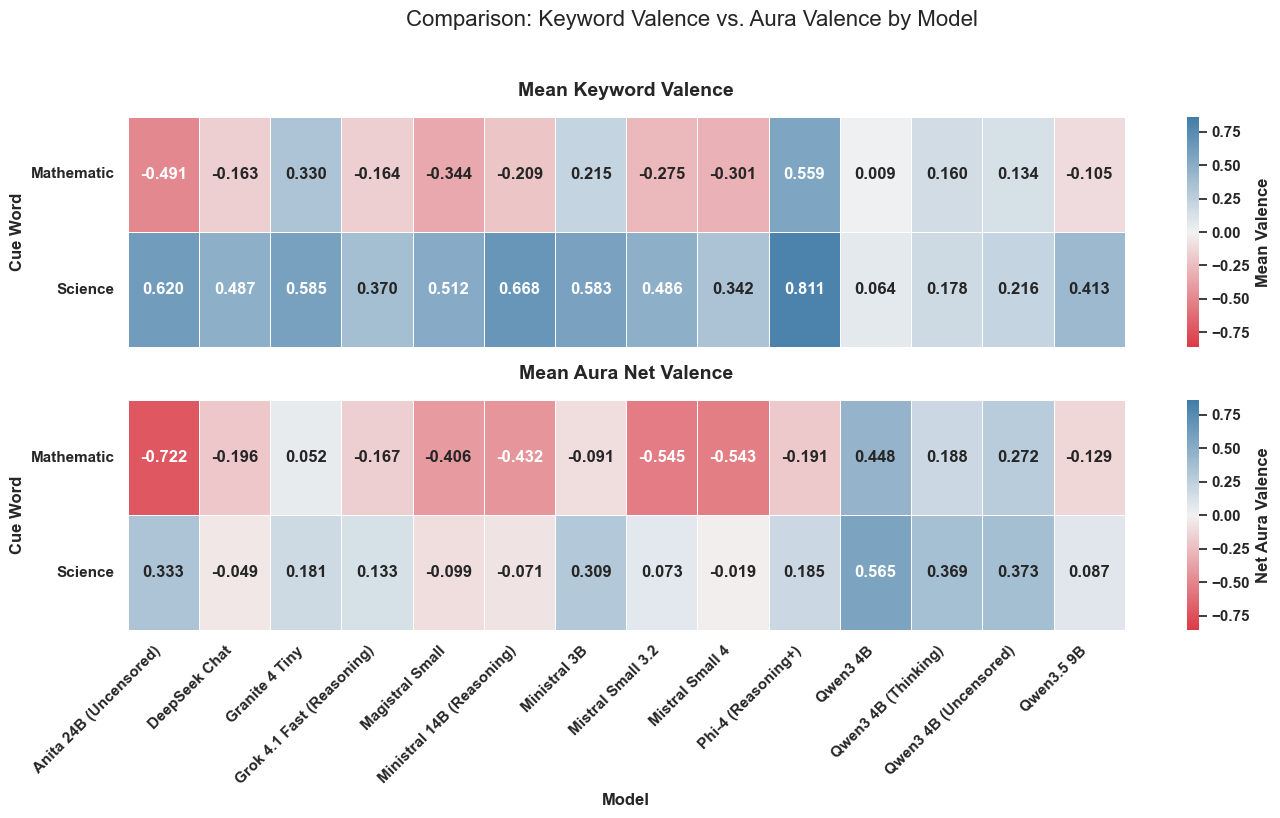

Plot successfully generated and saved!


In [20]:
# 1. Load the datasets
df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/aggregated_aura_valences.csv')

# Selected kw
subjects = ["mathematic", "science"]

# Clean up model names in the aura dataset to match the wide dataset
df_aura['model_name'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)
df_aura = df_aura[df_aura["cue_word"].isin(subjects)]

# 2. Calculate the mean keyword valence per model and cue word
agg_wide = df_wide.groupby(['model_name', 'cue_word'])['valence_cue_word'].mean().reset_index()

# 3. Merge the two datasets together
merged = pd.merge(agg_wide, df_aura, on=['model_name', 'cue_word'], how='inner')

# Clean model names and capitalize cue words for a cleaner plot display
merged['model_name_short'] = merged['model_name'].str.replace('MANX_LLM_', '')
merged['cue_word_disp'] = merged['cue_word'].str.capitalize()

# 4. Create Pivot Tables (Matrices) for the heatmaps
# INVERTED: Cue Words are now rows (index) and Models are columns
pivot_kw = merged.pivot(index='cue_word_disp', columns='model_name_short', values='valence_cue_word')
pivot_aura = merged.pivot(index='cue_word_disp', columns='model_name_short', values='aura_net_valence')

# Ensure rows and columns are sorted alphabetically so both heatmaps align perfectly
pivot_kw = pivot_kw.sort_index(axis=0).sort_index(axis=1)
pivot_aura = pivot_aura.sort_index(axis=0).sort_index(axis=1)

# 5. Set up the figure with 2 rows and 1 column
# Changed to sharex=True since the models are now on the X-axis
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Define a diverging colormap (Red for negative, Blue for positive)
cmap = sns.diverging_palette(10, 240, as_cmap=True)

# Find the global min and max across BOTH datasets to share the exact same color scale
vmin = min(pivot_kw.min().min(), pivot_aura.min().min())
vmax = max(pivot_kw.max().max(), pivot_aura.max().max())

# Make the limits symmetric around 0 so pure white is always exactly neutral
limit = max(abs(vmin), abs(vmax))
limit = round(limit + 0.05, 2)

# 6. Plot the first heatmap: Mean Keyword Valence (Top plot)
sns.heatmap(pivot_kw, ax=axes[0], cmap=cmap, center=0, vmin=-limit, vmax=limit, 
            annot=True, fmt=".3f", cbar_kws={'label': 'Mean Valence'}, linewidths=.5)
axes[0].set_title('Mean Keyword Valence', fontsize=14, pad=15)
axes[0].set_ylabel('Cue Word', fontsize=12)
axes[0].set_xlabel('') # Hide x-label on the top plot since they share the x-axis
axes[0].tick_params(axis='y', rotation=0)

# 7. Plot the second heatmap: Mean Aura Net Valence (Bottom plot)
sns.heatmap(pivot_aura, ax=axes[1], cmap=cmap, center=0, vmin=-limit, vmax=limit, 
            annot=True, fmt=".3f", cbar_kws={'label': 'Net Aura Valence'}, linewidths=.5)
axes[1].set_title('Mean Aura Net Valence', fontsize=14, pad=15)
axes[1].set_ylabel('Cue Word', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].tick_params(axis='y', rotation=0)

# Rotate x-axis labels on the bottom plot so model names don't overlap
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

# 8. Final formatting and save
# Adjusted the y parameter slightly for the suptitle so it doesn't overlap the new layout
plt.suptitle('Comparison: Keyword Valence vs. Aura Valence by Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("./visualizations/Keywords_Aura_comparison_heatmap_horizontal.svg", dpi=300,format="svg")

# Save the generated visualization
#plt.savefig('heatmap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Plot successfully generated and saved!")

In [21]:
df_aura.head()

,model_name,cue_word,aura_positive_fraction,aura_negative_fraction,aura_net_valence,total_associations
0,Mistral Small 4,mathematic,0.173913,0.717391,-0.543478,46
1,Mistral Small 4,science,0.461538,0.480769,-0.019231,52
3,DeepSeek Chat,mathematic,0.357143,0.553571,-0.196429,56
4,DeepSeek Chat,science,0.409836,0.459016,-0.049180,61
6,Grok 4.1 Fast (Reasoning),mathematic,0.366667,0.533333,-0.166667,90


In [22]:
df_wide.head()

,run_id,cue_word,valence_cue_word,association_1,association_2,association_3,valence_association_1,valence_association_2,valence_association_3,model_name
0,379a6b95de,ai,0.0,artificial,intelligence,technology,-1,1.0,0.0,Mistral Small 4
1,379a6b95de,algorithm,0.0,code,computation,logic,0,0.0,0.0,Mistral Small 4
2,379a6b95de,anxiety,-1.0,stress,fear,worry,-1,-1.0,-1.0,Mistral Small 4
3,379a6b95de,art,1.0,creativity,paint,expression,1,0.0,0.0,Mistral Small 4
4,379a6b95de,biology,1.0,life,cell,evolution,1,0.0,0.0,Mistral Small 4


In [23]:
df_aura.head()

,model_name,cue_word,aura_positive_fraction,aura_negative_fraction,aura_net_valence,total_associations
0,Mistral Small 4,mathematic,0.173913,0.717391,-0.543478,46
1,Mistral Small 4,science,0.461538,0.480769,-0.019231,52
3,DeepSeek Chat,mathematic,0.357143,0.553571,-0.196429,56
4,DeepSeek Chat,science,0.409836,0.459016,-0.049180,61
6,Grok 4.1 Fast (Reasoning),mathematic,0.366667,0.533333,-0.166667,90


In [24]:
merged.head()

,model_name,cue_word,valence_cue_word,aura_positive_fraction,aura_negative_fraction,aura_net_valence,total_associations,model_name_short,cue_word_disp
0,Anita 24B (Uncensored),mathematic,-0.490991,0.083333,0.805556,-0.722222,36,Anita 24B (Uncensored),Mathematic
1,Anita 24B (Uncensored),science,0.620120,0.638889,0.305556,0.333333,36,Anita 24B (Uncensored),Science
2,DeepSeek Chat,mathematic,-0.162500,0.357143,0.553571,-0.196429,56,DeepSeek Chat,Mathematic
3,DeepSeek Chat,science,0.487000,0.409836,0.459016,-0.049180,61,DeepSeek Chat,Science
4,Granite 4 Tiny,mathematic,0.330146,0.402597,0.350649,0.051948,77,Granite 4 Tiny,Mathematic


Generating plot for: mathematic


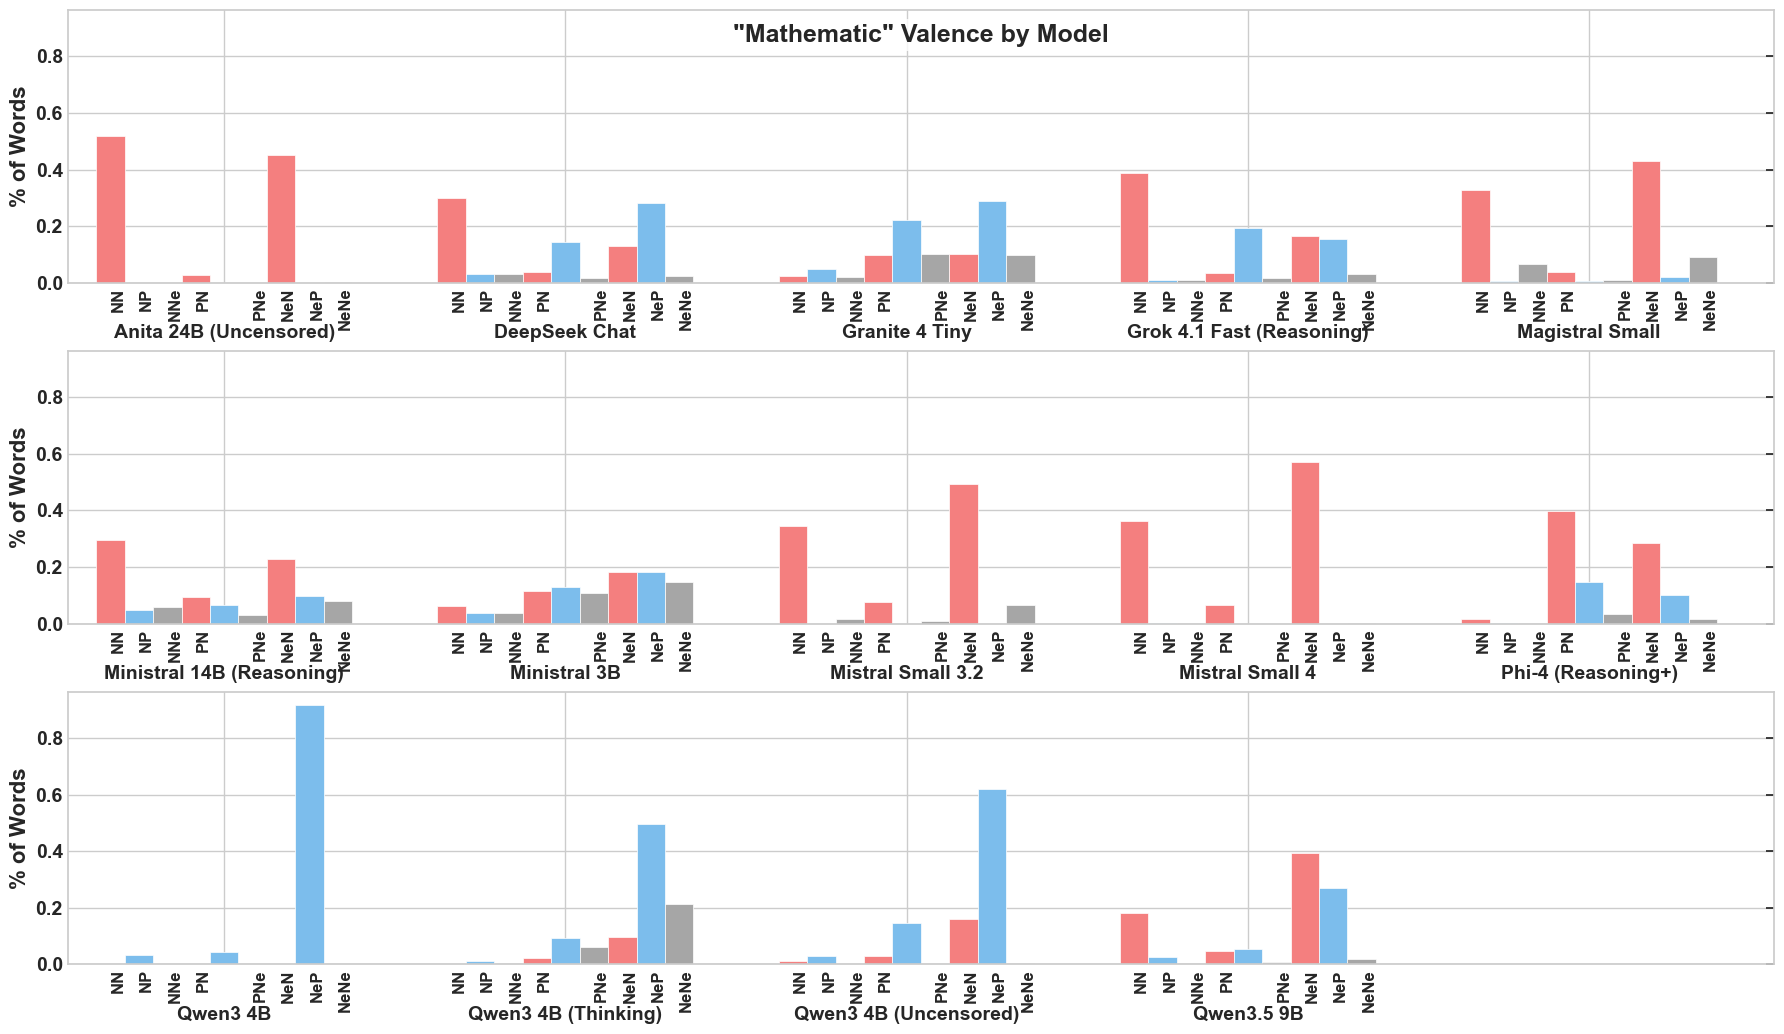

Generating plot for: science


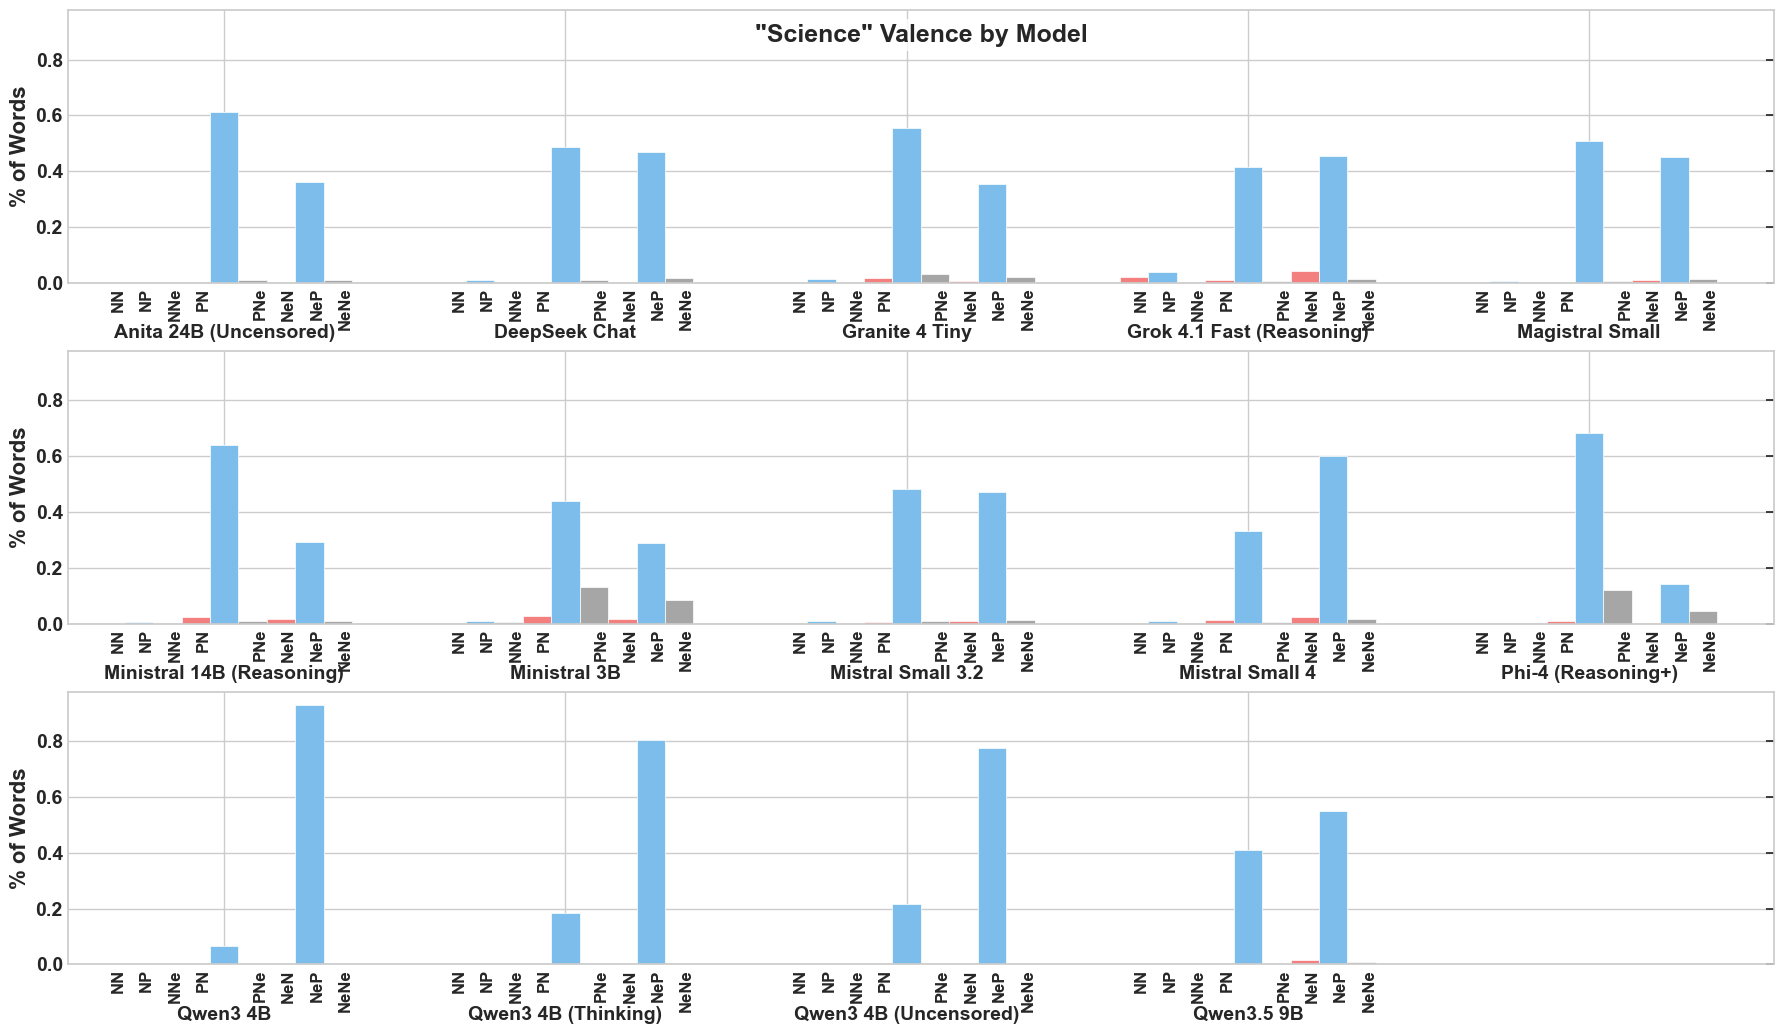

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# 1. Load the datasets
df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/run_level_aura_valences.csv')

# Selected kw
subjects = ["mathematic", "science"]

# Clean up model names
df_aura['model_name_short'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)
df_wide['model_name_short'] = df_wide['model_name'].str.replace('MANX_LLM_', '').replace(FOLDER_NAME_MAPPING)

# 2. Instance-Level Merge
# NOTE: Make sure df_wide and df_aura are defined before running this
merged = pd.merge(df_wide, df_aura, on=['model_name_short', 'cue_word', 'run_id'], how='inner')
merged = merged[merged["cue_word"].isin(subjects)]

# 3. Categorize Valences into N, P, Ne
def categorize_valence(val):
    if val > 0: return 'P'
    elif val < 0: return 'N'
    else: return 'Ne'

merged['kw_cat'] = merged['valence_cue_word'].apply(categorize_valence)
merged['aura_cat'] = merged['aura_net_valence'].apply(categorize_valence)

# Combine them into the 9 categories (e.g., 'N' + 'N' = 'NN')
merged['valence_pair'] = merged['kw_cat'] + merged['aura_cat']

# The exact 9 categories from the image in order
categories = ['NN', 'NP', 'NNe', 'PN', 'PP', 'PNe', 'NeN', 'NeP', 'NeNe']
# Colors map to the second letter of the pair: N=Red, P=Blue, Ne=Gray
colors = ['#f47f7f', '#7cbdec', '#a6a6a6'] * 3 

# 4. Define a plotting function for a single keyword
def plot_keyword_combinations(df, keyword, row_layout=[5, 5, 4]):
    """
    Plots the combinations. 
    row_layout controls exactly how many models appear on each line.
    """
    # Filter for the specific keyword
    df_kw = df[df['cue_word'] == keyword]
    
    # Calculate the proportion of each pair per model
    proportions = df_kw.groupby('model_name_short')['valence_pair'].value_counts(normalize=True).unstack(fill_value=0)
    
    # Ensure all 9 columns exist even if some pairs never occurred
    for cat in categories:
        if cat not in proportions.columns:
            proportions[cat] = 0
            
    proportions = proportions[categories] # Enforce strict column order
    models = sorted(proportions.index.tolist())
    
    # --- NEW LOGIC: Custom Row Layout (e.g., 5, 5, 4) ---
    models_rows = []
    start_idx = 0
    for count in row_layout:
        end_idx = start_idx + count
        chunk = models[start_idx:end_idx]
        if chunk:  # Only add if there are models in this chunk
            models_rows.append(chunk)
        start_idx = end_idx
        
    num_rows = len(models_rows)
    
    # Calculate maximum required width to keep bar sizes consistent across rows
    max_models_in_row = max(len(r) for r in models_rows)
    # The limit ensures the 4-model row doesn't stretch visually to fill the space of 5
    max_x_limit = max_models_in_row * (len(categories) + 3)
    
    # --- REDUCED UNUSED SPACE ---
    # Scaled down from 4.5 to 3.5 inches per row to reduce dead vertical space
    fig, axes = plt.subplots(num_rows, 1, figsize=(18, 3.5 * num_rows), sharey=True)
    
    # If there's only 1 row, plt.subplots returns a single axes object, not an array. We fix that here.
    if num_rows == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        current_models = models_rows[i]
        
        major_ticks = []
        minor_ticks = []
        minor_labels = []
        
        for j, model in enumerate(current_models):
            model_data = proportions.loc[model]
            
            # Calculate x positions for the 9 bars of this model
            # Adding a gap of 3 empty spaces between models
            x_start = j * (len(categories) + 3) 
            x_pos = np.arange(x_start, x_start + len(categories))
            
            # Plot the 9 bars
            for k, cat in enumerate(categories):
                ax.bar(x_pos[k], model_data[cat], width=1.0, color=colors[k], edgecolor='white', linewidth=0.5)
            
            # Store tick locations for formatting
            minor_ticks.extend(x_pos)
            minor_labels.extend(categories)
            # Center the major tick (Model Name) under the 9 bars
            major_ticks.append(x_start + len(categories)/2 - 0.5)
            
        # --- Axis Formatting & INCREASED FONT SIZES ---
        ax.set_xticks(minor_ticks, minor=True)
        
        # ---> CHANGED HERE: Added rotation=45 and ha='right' to prevent overlapping <---
        ax.set_xticklabels(minor_labels, minor=True, fontsize=12, rotation=90, ha='right', rotation_mode='anchor') 
        
        ax.tick_params(axis='x', which='minor', length=0)
        
        ax.set_xticks(major_ticks)
        ax.set_xticklabels(current_models, fontsize=16, fontweight='bold') # Increased from 14 to 16
        # Pushed the major labels slightly further down (pad=30) so they don't hit the rotated minor labels
        ax.tick_params(axis='x', which='major', pad=30, length=0)
        
        ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, labelsize=14)
        ax.set_ylabel('% of Words', fontsize=16) # Increased from 12 to 16
        
        # Enforce consistent x-axis limits so bars are the same width on the last row
        ax.set_xlim(-1.5, max_x_limit - 1.5)
        
        # --- CENTERED TITLES (ONLY ON FIRST ROW) ---
        if i == 0:
            ax.text(0.5, 0.95, f'"{keyword.capitalize()}" Valence by Model', 
                    transform=ax.transAxes, fontsize=18, fontweight='bold', va='top', ha='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    # --- REDUCED UNUSED SPACE ---
    # Lowered h_pad to squeeze the rows together
    plt.tight_layout(h_pad=0.5)
    plt.savefig(f"./visualizations/{keyword}_Aura_comparison.svg", dpi=300, format="svg")
    plt.show()

# 5. Generate the plots for both keywords
# (Assuming `merged` dataset is successfully created in Step 2)
for kw in subjects:
    print(f"Generating plot for: {kw}")
    plot_keyword_combinations(merged, kw, row_layout=[5, 5, 4])

Generating plot for: mathematic


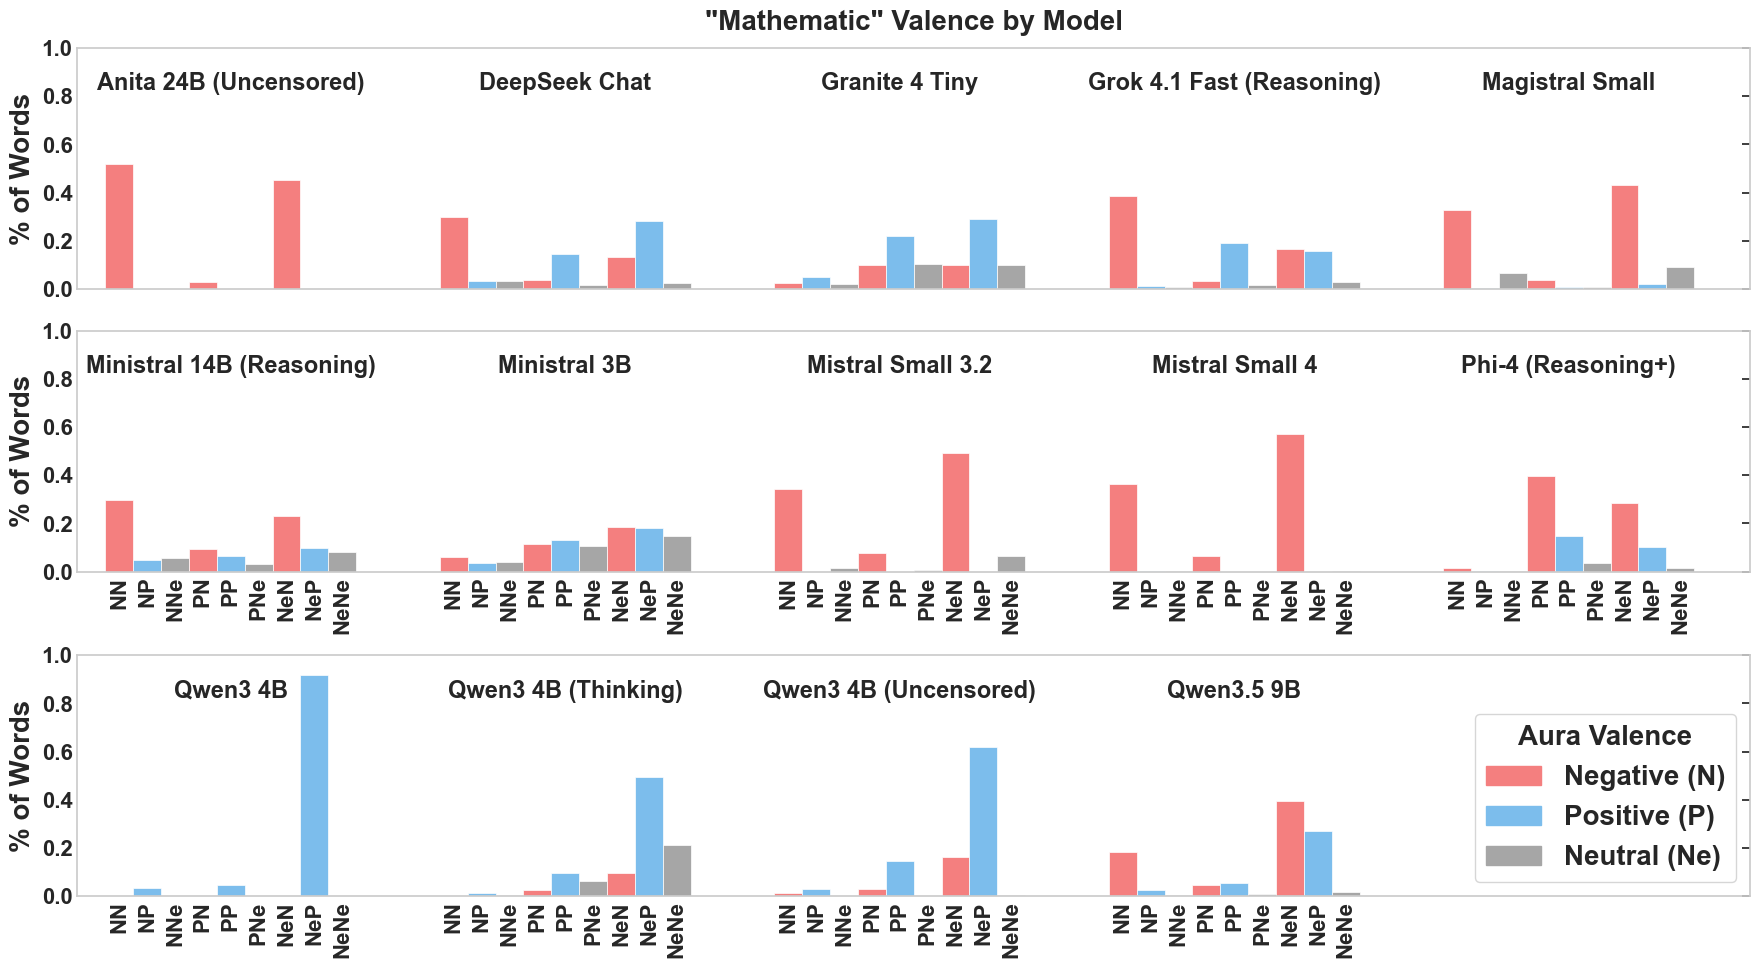

Generating plot for: science


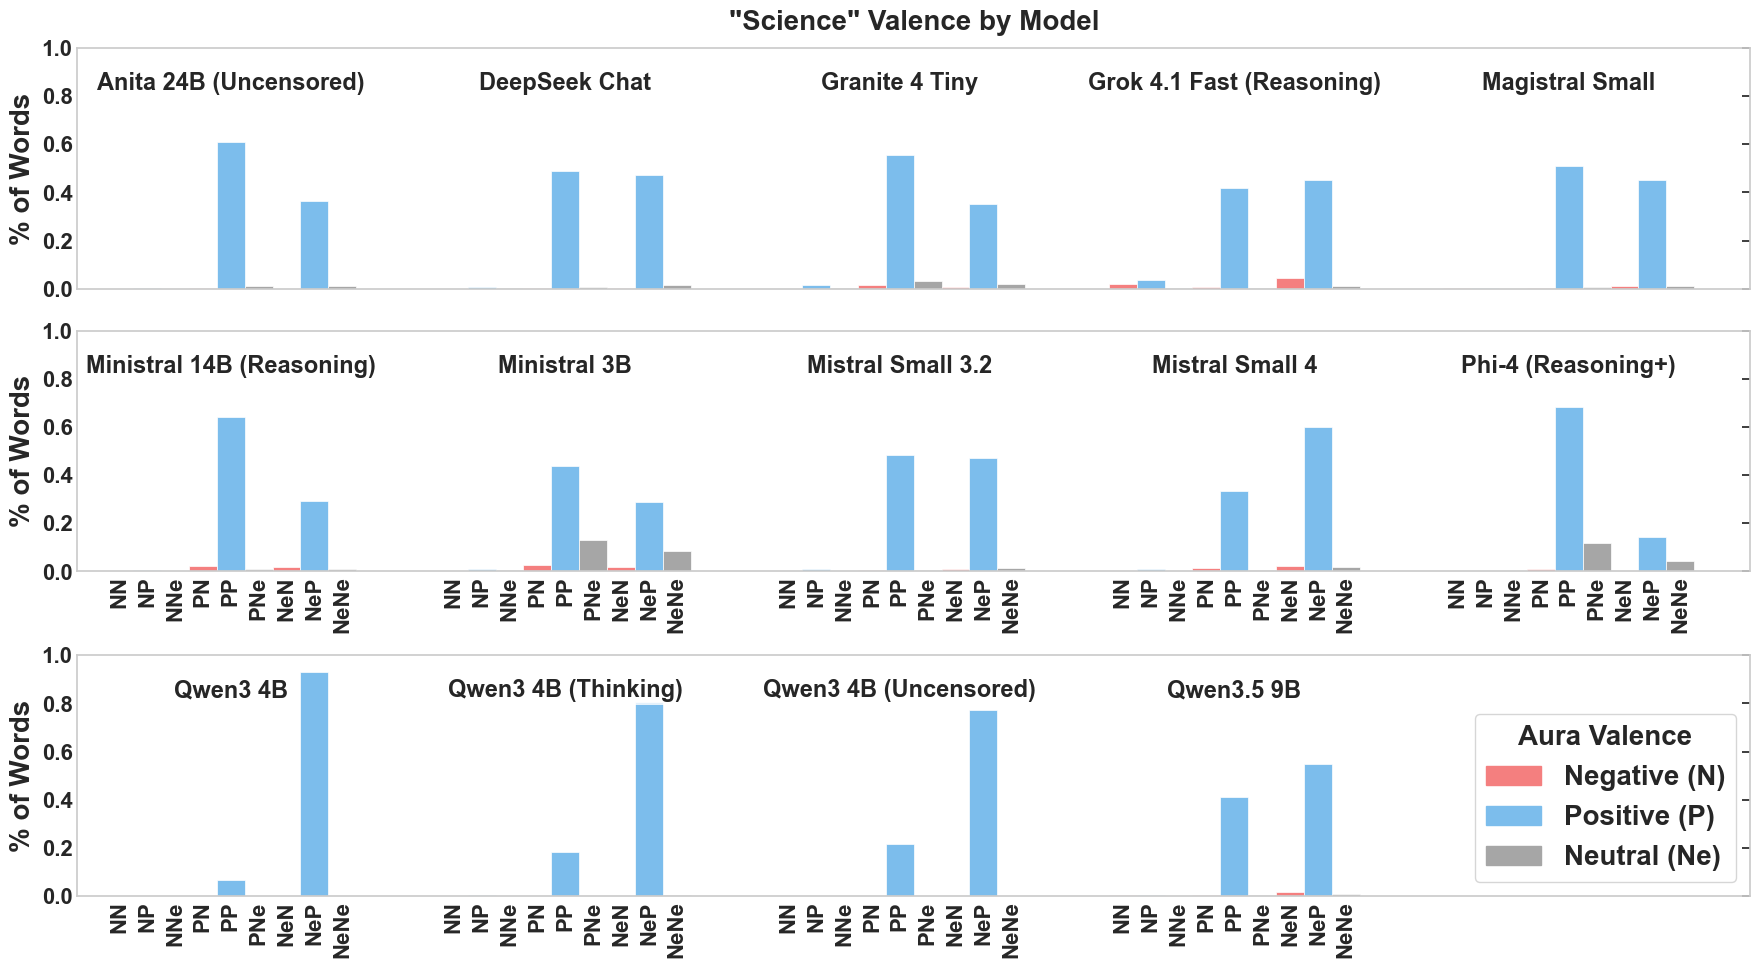

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import math

# Set global base font size
plt.rcParams.update({
    'font.size': 20,
    'axes.labelweight': 'bold',
    'font.weight': 'bold'
})

# 1. Load the datasets
# df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/run_level_aura_valences.csv')

# Selected kw
subjects = ["mathematic", "science"]

# Clean up model names
df_aura['model_name_short'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)
df_wide['model_name_short'] = df_wide['model_name'].str.replace('MANX_LLM_', '').replace(FOLDER_NAME_MAPPING)

# 2. Instance-Level Merge
merged = pd.merge(df_wide, df_aura, on=['model_name_short', 'cue_word', 'run_id'], how='inner')
merged = merged[merged["cue_word"].isin(subjects)]

# 3. Categorize Valences into N, P, Ne
def categorize_valence(val):
    if val > 0: return 'P'
    elif val < 0: return 'N'
    else: return 'Ne'

merged['kw_cat'] = merged['valence_cue_word'].apply(categorize_valence)
merged['aura_cat'] = merged['aura_net_valence'].apply(categorize_valence)

# Combine them into the 9 categories (e.g., 'N' + 'N' = 'NN')
merged['valence_pair'] = merged['kw_cat'] + merged['aura_cat']

# The exact 9 categories from the image in order
categories = ['NN', 'NP', 'NNe', 'PN', 'PP', 'PNe', 'NeN', 'NeP', 'NeNe']
colors = ['#f47f7f', '#7cbdec', '#a6a6a6'] * 3 

# 4. Define a plotting function for a single keyword
def plot_keyword_combinations(df, keyword, row_layout=[5, 5, 4]):
    df_kw = df[df['cue_word'] == keyword]
    
    proportions = df_kw.groupby('model_name_short')['valence_pair'].value_counts(normalize=True).unstack(fill_value=0)
    
    for cat in categories:
        if cat not in proportions.columns:
            proportions[cat] = 0
            
    proportions = proportions[categories]
    models = sorted(proportions.index.tolist())
    
    models_rows = []
    start_idx = 0
    for count in row_layout:
        end_idx = start_idx + count
        chunk = models[start_idx:end_idx]
        if chunk:  
            models_rows.append(chunk)
        start_idx = end_idx
        
    num_rows = len(models_rows)
    max_models_in_row = max(len(r) for r in models_rows)
    max_x_limit = max_models_in_row * (len(categories) + 3)
    
    fig, axes = plt.subplots(num_rows, 1, figsize=(18, 3.5 * num_rows), sharey=True)
    if num_rows == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.grid(False)
        current_models = models_rows[i]
        
        category_ticks = []
        category_labels = []
        
        for j, model in enumerate(current_models):
            model_data = proportions.loc[model]
            
            x_start = j * (len(categories) + 3) 
            x_pos = np.arange(x_start, x_start + len(categories))
            
            for k, cat in enumerate(categories):
                ax.bar(x_pos[k], model_data[cat], width=1.0, color=colors[k], edgecolor='white', linewidth=0.5)
            
            category_ticks.extend(x_pos)
            category_labels.extend(categories)
            
            # Center the model tick under the 9 bars
            model_center = x_start + len(categories)/2 - 0.5
            
            # Place the model name inside the plot at the top of the group
            ax.text(model_center, 0.90, model, 
                    fontsize=17, fontweight='bold', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
            
        # Perfect Alignment
        ax.set_xticks(category_ticks)
        
        if i == 0:
            # First row: No x-axis labels
            ax.set_xticklabels([]) 
        else:
            # Second and third row: Show x-axis labels
            ax.set_xticklabels(category_labels, fontsize=16, rotation=90, ha='center', va='top') 
            
        ax.tick_params(axis='x', which='major', length=0)
        
        ax.tick_params(axis='y', which='major', direction='in', right=True, labelsize=16)
        ax.set_ylabel('% of Words', fontsize=20, fontweight='bold') 
        ax.set_xlim(-1.5, max_x_limit - 1.5)
        
        # Enforce Y-limits so the inside text (y=0.90) stays consistently placed
        ax.set_ylim(0, 1.0)
        
        if i == 0:
            # Shifted title slightly up to avoid collision with the model text labels
            ax.text(0.5, 1.05, f'"{keyword.capitalize()}" Valence by Model', 
                    transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    legend_patches = [
        mpatches.Patch(color='#f47f7f', label='Negative (N)'),
        mpatches.Patch(color='#7cbdec', label='Positive (P)'),
        mpatches.Patch(color='#a6a6a6', label='Neutral (Ne)')
    ]
    
    # Force bold weight and larger size for both the labels and the title
    leg = axes[-1].legend(
        handles=legend_patches, 
        loc='lower right', 
        title='Aura Valence', 
        prop={'size': 20, 'weight': 'bold'} 
    )
    leg.get_title().set_fontweight('bold') 
    leg.get_title().set_fontsize(20)       

    plt.tight_layout(h_pad=0.5)
    
    # --- NEW MODIFICATION: Shift the first row down ---
    if num_rows > 1:
        fig.canvas.draw()  # Force layout calculation
        pos = axes[0].get_position()
        # Shift the first plot down by 0.04 (adjust this number if you want it closer/further)
        axes[0].set_position([pos.x0, pos.y0 - 0.04, pos.width, pos.height])

    # plt.savefig(f"./visualizations/{keyword}_Aura_comparison.svg", dpi=300, format="svg")
    plt.show()

# 5. Generate the plots for both keywords
for kw in subjects:
    print(f"Generating plot for: {kw}")
    plot_keyword_combinations(merged, kw, row_layout=[5, 5, 4])

Generating plot for: mathematic


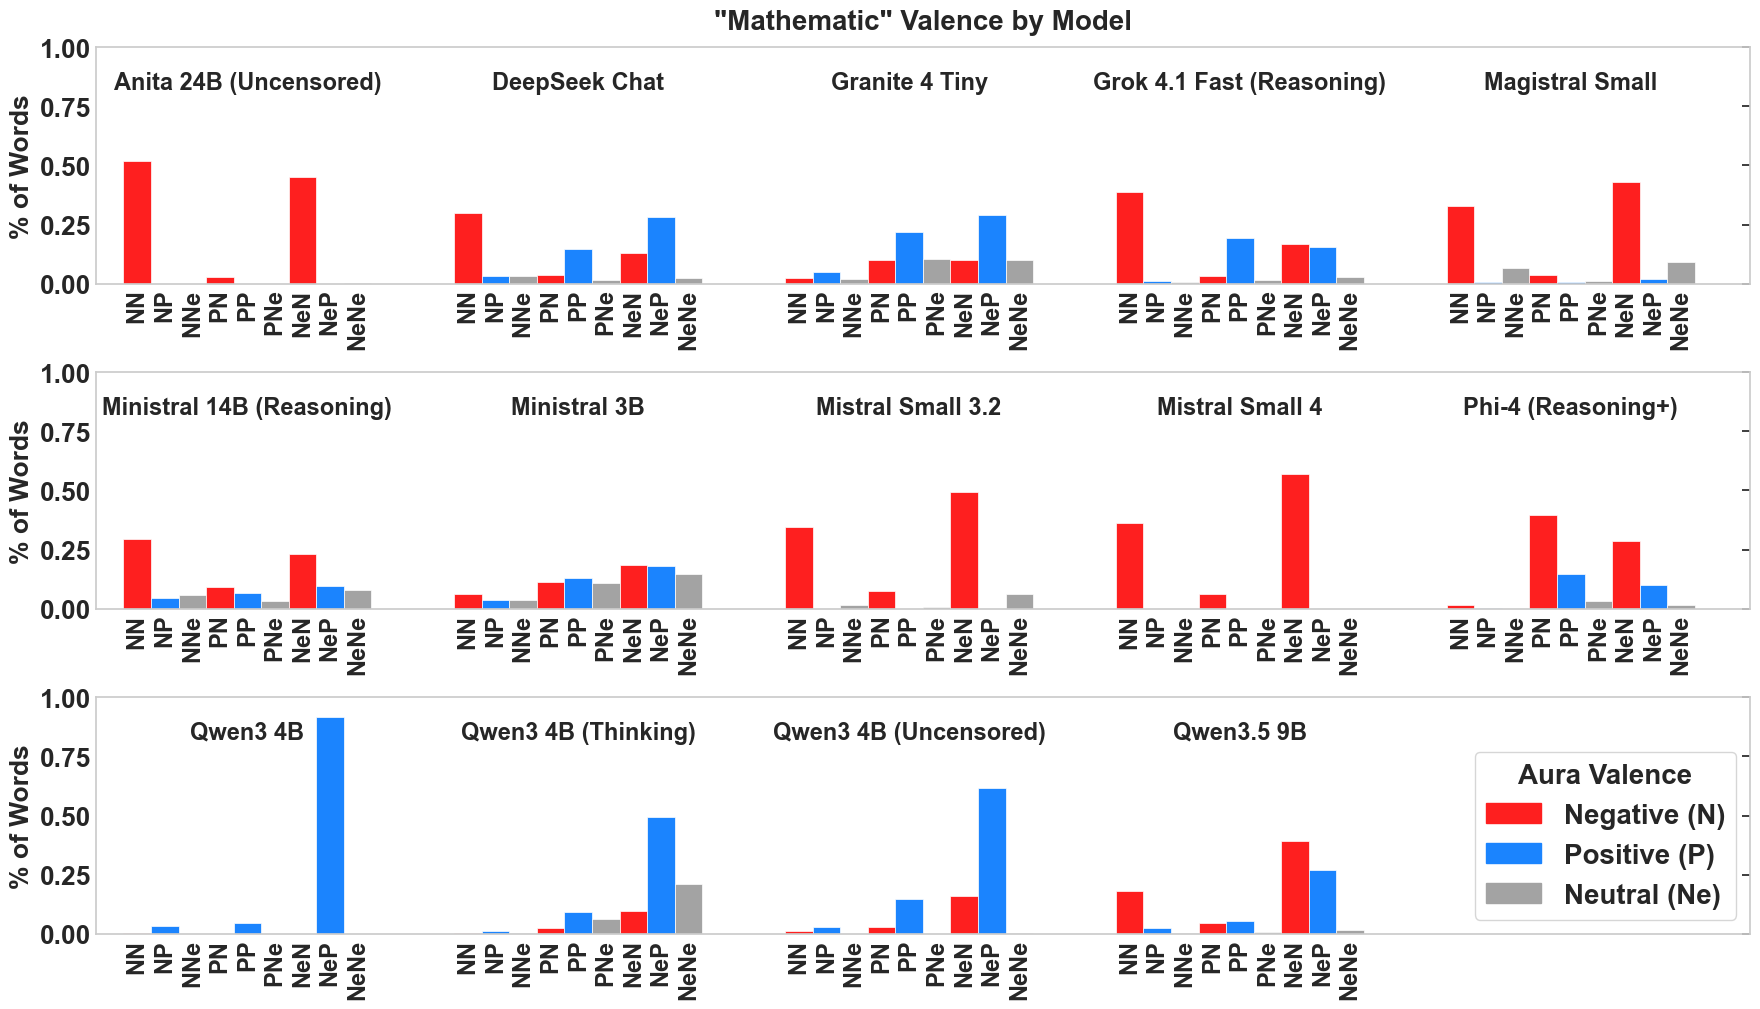

Generating plot for: science


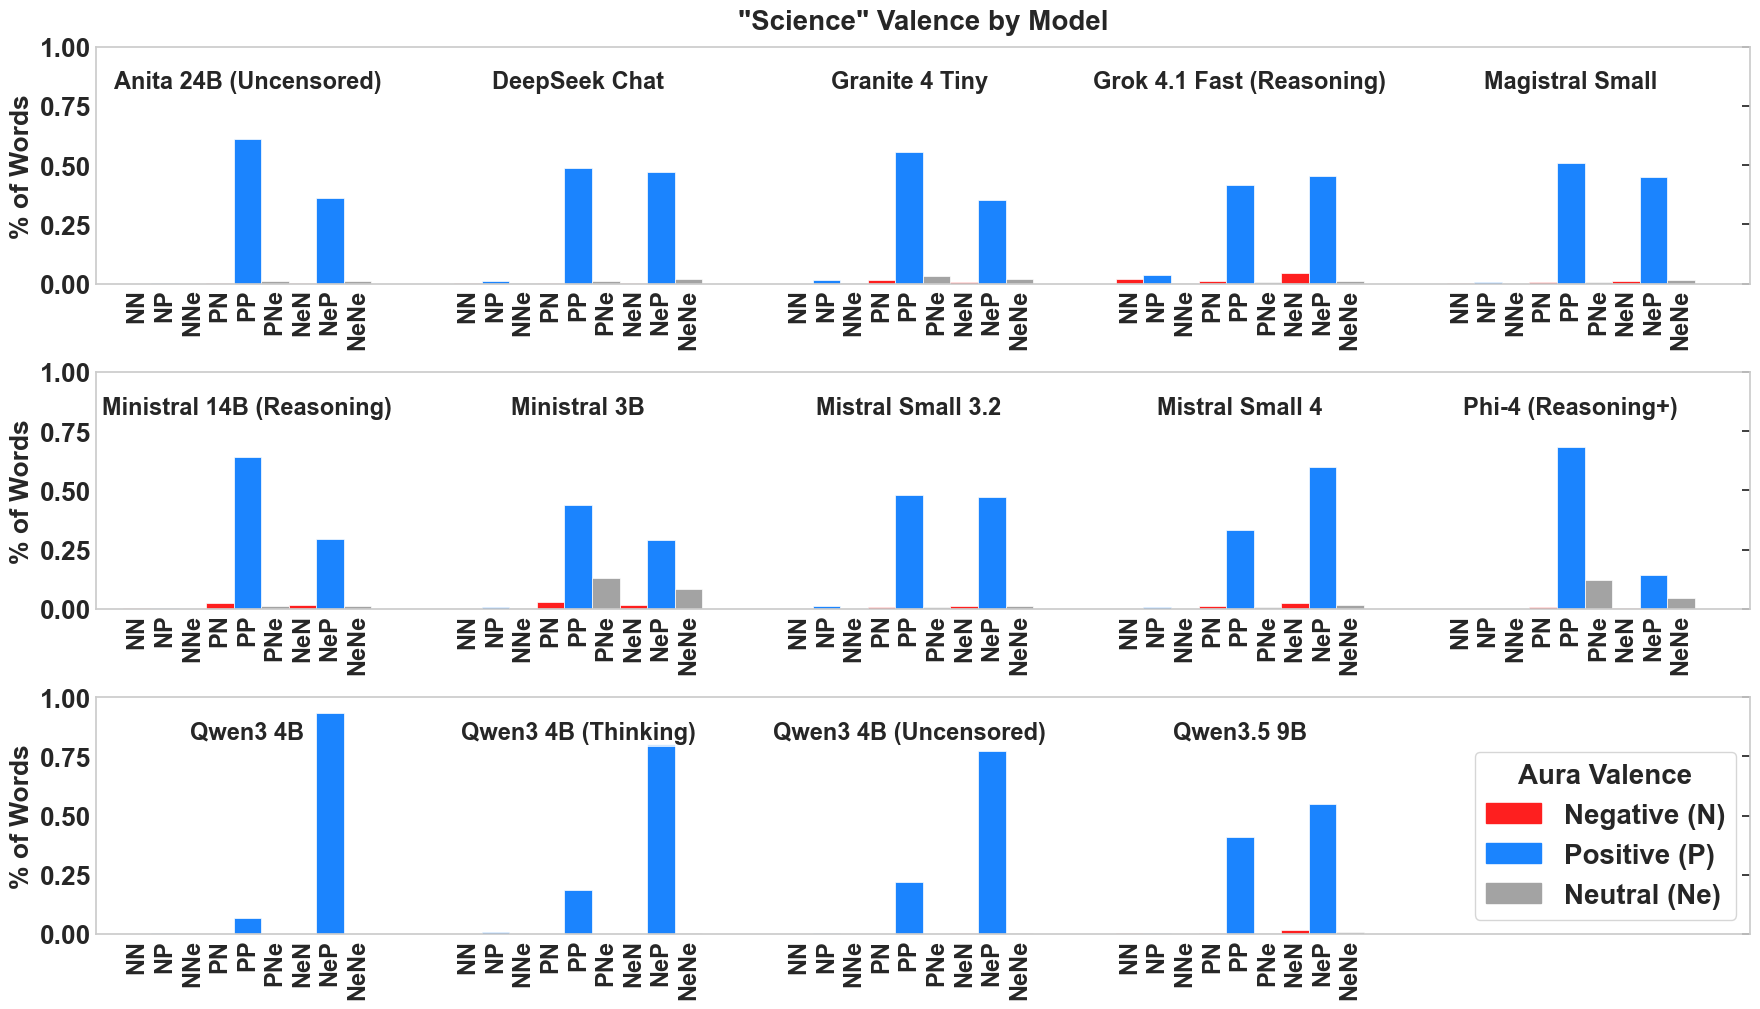

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import math

# Set global base font size
plt.rcParams.update({
    'font.family': 'sans-serif',   # Add a specific font like 'Arial' here if needed
    'font.size': 20,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'legend.title_fontsize': 20
})

# 1. Load the datasets
# df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/run_level_aura_valences.csv')

# Selected kw
subjects = ["mathematic", "science"]

# Clean up model names
df_aura['model_name_short'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)
df_wide['model_name_short'] = df_wide['model_name'].str.replace('MANX_LLM_', '').replace(FOLDER_NAME_MAPPING)

# 2. Instance-Level Merge
merged = pd.merge(df_wide, df_aura, on=['model_name_short', 'cue_word', 'run_id'], how='inner')
merged = merged[merged["cue_word"].isin(subjects)]

# 3. Categorize Valences into N, P, Ne
def categorize_valence(val):
    if val > 0: return 'P'
    elif val < 0: return 'N'
    else: return 'Ne'

merged['kw_cat'] = merged['valence_cue_word'].apply(categorize_valence)
merged['aura_cat'] = merged['aura_net_valence'].apply(categorize_valence)

# Combine them into the 9 categories (e.g., 'N' + 'N' = 'NN')
merged['valence_pair'] = merged['kw_cat'] + merged['aura_cat']

# The exact 9 categories from the image in order
categories = ['NN', 'NP', 'NNe', 'PN', 'PP', 'PNe', 'NeN', 'NeP', 'NeNe']
colors = ['#fe1f1f', '#1b84fe',"#a3a3a3"] * 3 

# 4. Define a plotting function for a single keyword
def plot_keyword_combinations(df, keyword, row_layout=[5, 5, 4]):
    df_kw = df[df['cue_word'] == keyword]
    
    proportions = df_kw.groupby('model_name_short')['valence_pair'].value_counts(normalize=True).unstack(fill_value=0)
    
    for cat in categories:
        if cat not in proportions.columns:
            proportions[cat] = 0
            
    proportions = proportions[categories]
    models = sorted(proportions.index.tolist())
    
    models_rows = []
    start_idx = 0
    for count in row_layout:
        end_idx = start_idx + count
        chunk = models[start_idx:end_idx]
        if chunk:  
            models_rows.append(chunk)
        start_idx = end_idx
        
    num_rows = len(models_rows)
    max_models_in_row = max(len(r) for r in models_rows)
    max_x_limit = max_models_in_row * (len(categories) + 3)
    
    fig, axes = plt.subplots(num_rows, 1, figsize=(18, 3.5 * num_rows), sharey=True)
    if num_rows == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.grid(False)
        current_models = models_rows[i]
        
        category_ticks = []
        category_labels = []
        
        for j, model in enumerate(current_models):
            model_data = proportions.loc[model]
            
            x_start = j * (len(categories) + 3) 
            x_pos = np.arange(x_start, x_start + len(categories))
            
            for k, cat in enumerate(categories):
                ax.bar(x_pos[k], model_data[cat], width=1.0, color=colors[k], edgecolor='white', linewidth=0.5)
            
            category_ticks.extend(x_pos)
            category_labels.extend(categories)
            
            # Center the model tick under the 9 bars
            model_center = x_start + len(categories)/2 - 0.5
            
            # Place the model name inside the plot at the top of the group (kept at 16)
            ax.text(model_center, 0.90, model, 
                    fontsize=17, fontweight='bold', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
            
        # Perfect Alignment
        ax.set_xticks(category_ticks)
        
        # --- MODIFIED: Show x-axis labels on all rows ---
        ax.set_xticklabels(category_labels, fontsize=17, rotation=90, ha='center', va='top') 
            
        ax.tick_params(axis='x', which='major', length=0)
        
        # Kept tick labels at 16, changed ylabel to 16
        ax.tick_params(axis='y', which='major', direction='in', right=True, labelsize=19)
        ax.set_ylabel('% of Words', fontsize=19, fontweight='bold') 
        ax.set_xlim(-1.5, max_x_limit - 1.5)
        
        # Enforce Y-limits so the inside text (y=0.90) stays consistently placed
        ax.set_ylim(0, 1.0)
        
        if i == 0:
            # Changed title fontsize to 16
            ax.text(0.5, 1.05, f'"{keyword.capitalize()}" Valence by Model', 
                    transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    legend_patches = [
        mpatches.Patch(color='#fe1f1f', label='Negative (N)'),
        mpatches.Patch(color='#1b84fe', label='Positive (P)'),
        mpatches.Patch(color="#a3a3a3", label='Neutral (Ne)')
    ]
    
    # Legend items kept at 16
    leg = axes[-1].legend(
        handles=legend_patches, 
        loc='lower right', 
        title='Aura Valence', 
        prop={'size': 20, 'weight': 'bold'} 
    )
    leg.get_title().set_fontweight('bold') 
    # Changed legend title to 16
    leg.get_title().set_fontsize(20)       

    plt.tight_layout(h_pad=0.5)
    
    # Shift the first row down
    #if num_rows > 1:
        #fig.canvas.draw()  # Force layout calculation
        #pos = axes[0].get_position()
        #axes[0].set_position([pos.x0, pos.y0 - 0.04, pos.width, pos.height])

    plt.savefig(f"./visualizations/OFFICIAL_{keyword}_Aura_comparison.svg", dpi=300, format="svg")
    plt.show()

# 5. Generate the plots for both keywords
for kw in subjects:
    print(f"Generating plot for: {kw}")
    plot_keyword_combinations(merged, kw, row_layout=[5, 5, 4])

Generating plot for: mathematic


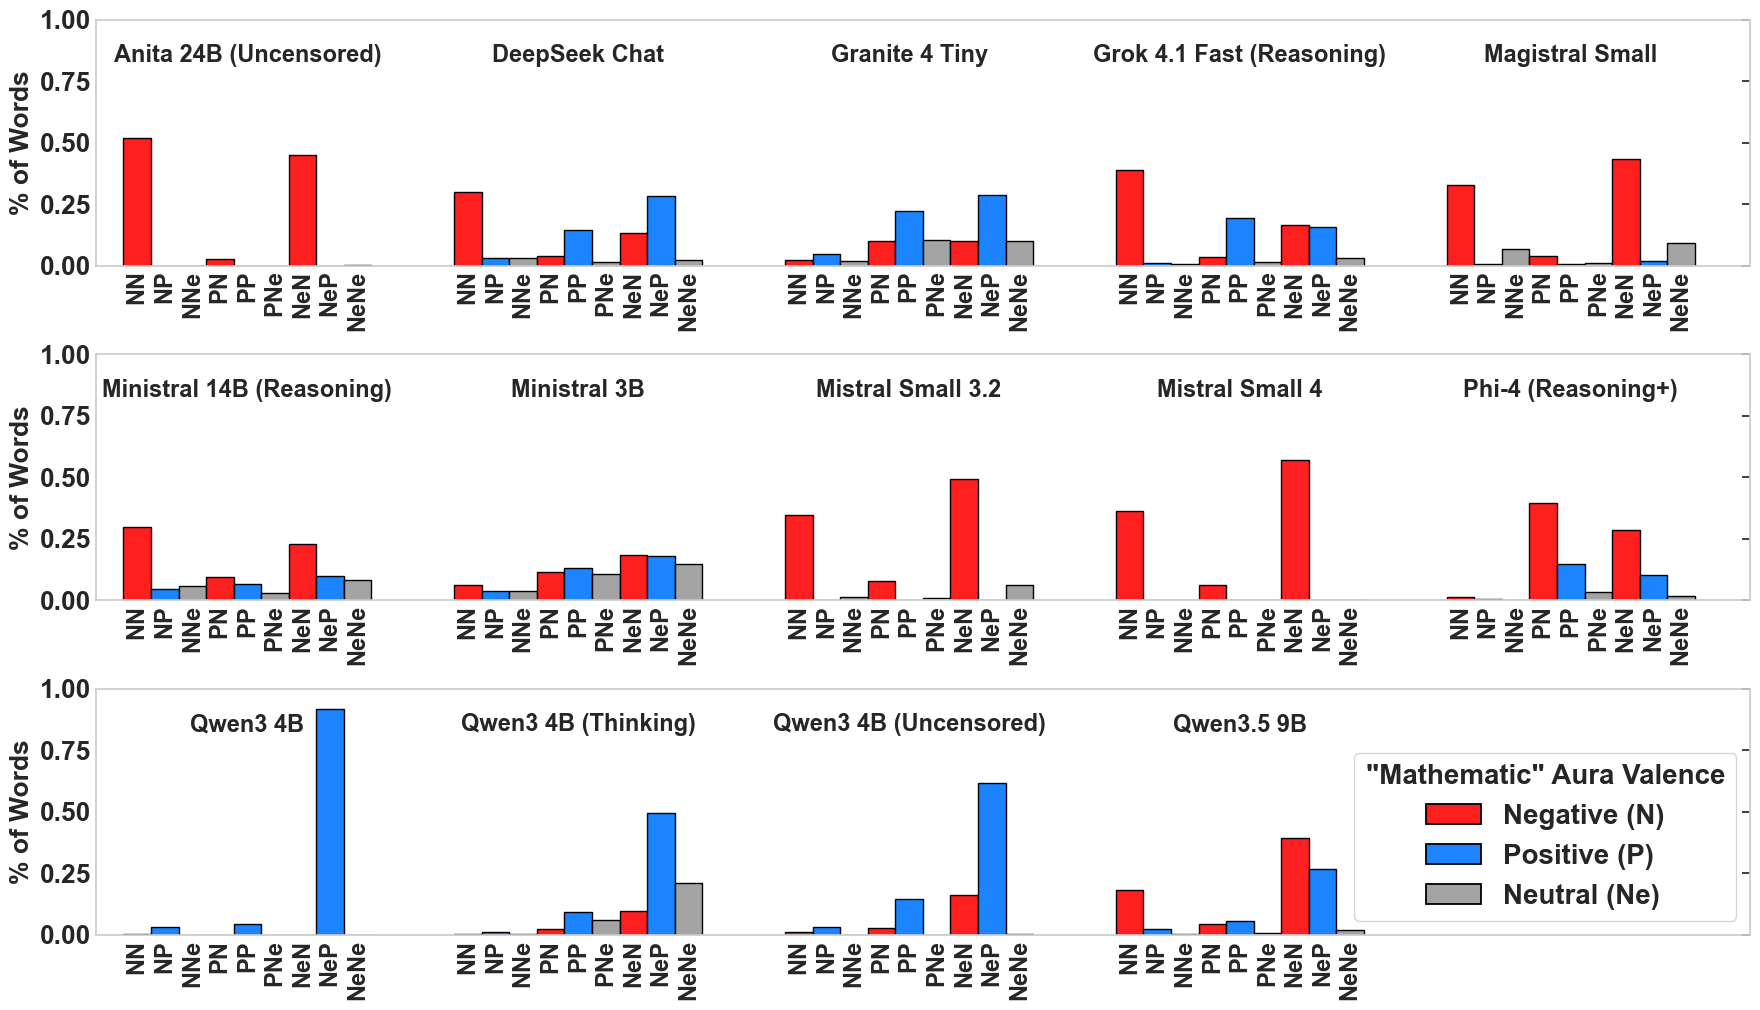

Generating plot for: science


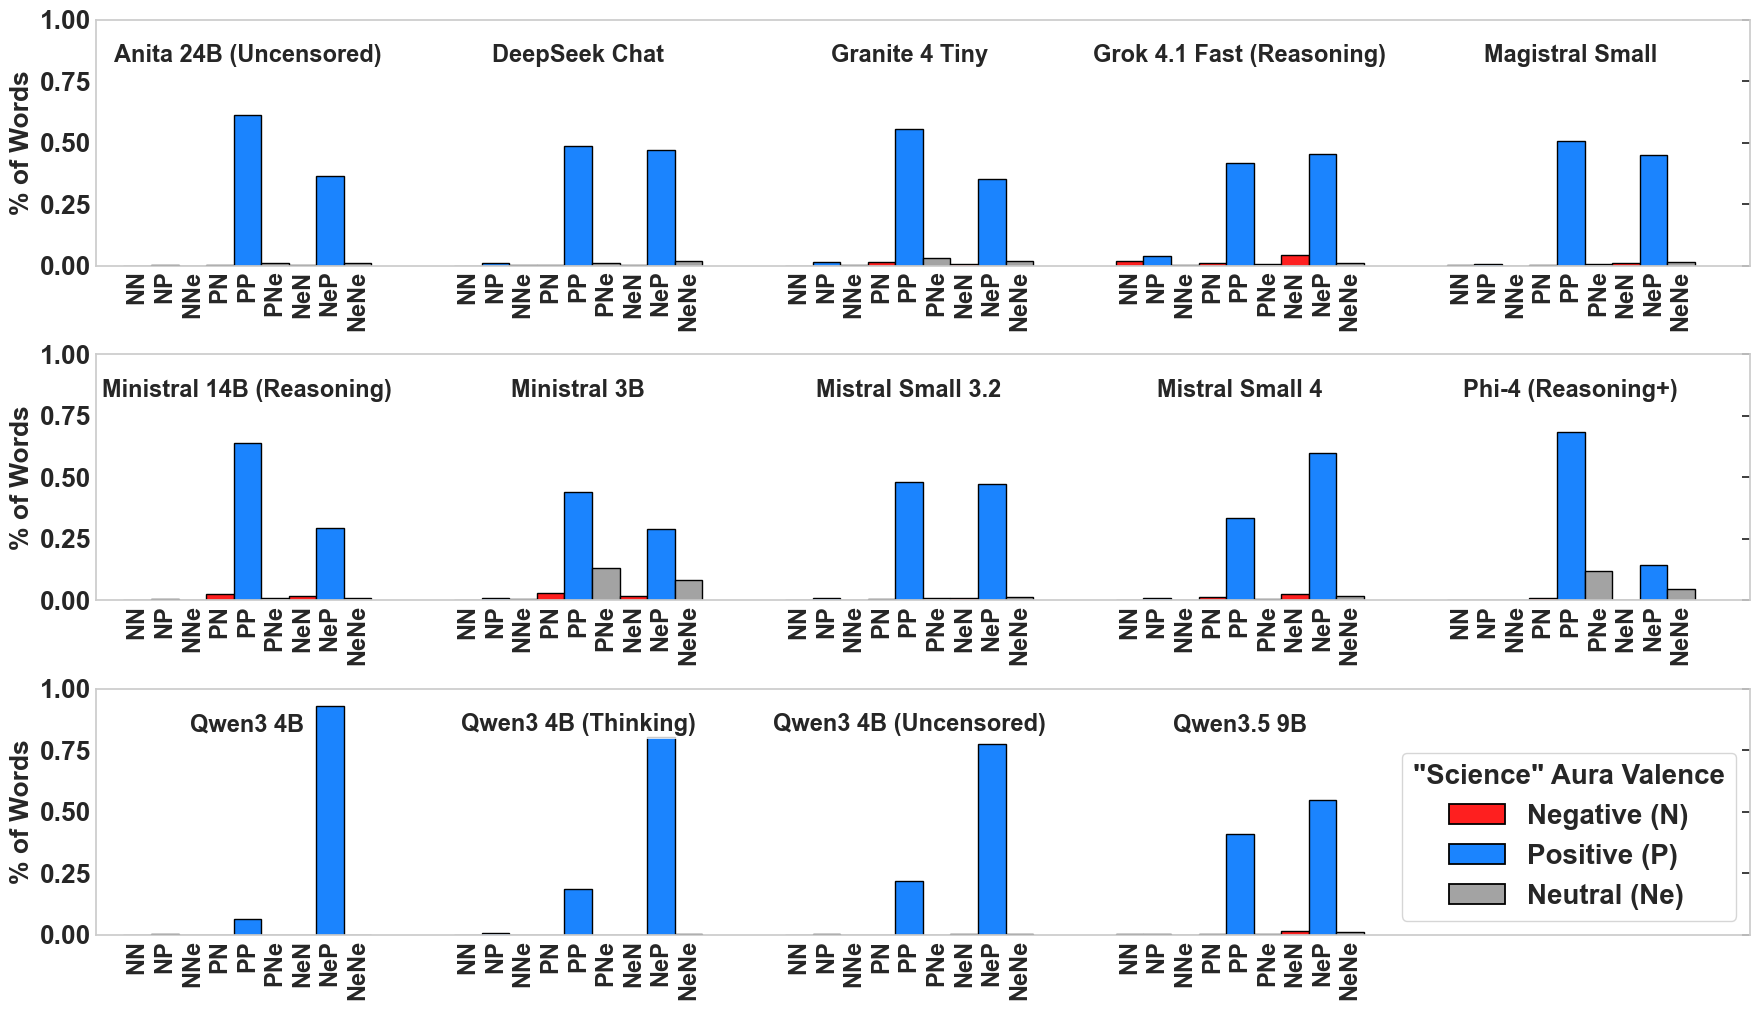

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import math

# Set global base font size
plt.rcParams.update({
    'font.family': 'sans-serif',   # Add a specific font like 'Arial' here if needed
    'font.size': 20,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'legend.title_fontsize': 20
})

# 1. Load the datasets
# df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/run_level_aura_valences.csv')

# Selected kw
subjects = ["mathematic", "science"]

# Clean up model names
df_aura['model_name_short'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)
df_wide['model_name_short'] = df_wide['model_name'].str.replace('MANX_LLM_', '').replace(FOLDER_NAME_MAPPING)

# 2. Instance-Level Merge
merged = pd.merge(df_wide, df_aura, on=['model_name_short', 'cue_word', 'run_id'], how='inner')
merged = merged[merged["cue_word"].isin(subjects)]

# 3. Categorize Valences into N, P, Ne
def categorize_valence(val):
    if val > 0: return 'P'
    elif val < 0: return 'N'
    else: return 'Ne'

merged['kw_cat'] = merged['valence_cue_word'].apply(categorize_valence)
merged['aura_cat'] = merged['aura_net_valence'].apply(categorize_valence)

# Combine them into the 9 categories (e.g., 'N' + 'N' = 'NN')
merged['valence_pair'] = merged['kw_cat'] + merged['aura_cat']

# The exact 9 categories from the image in order
categories = ['NN', 'NP', 'NNe', 'PN', 'PP', 'PNe', 'NeN', 'NeP', 'NeNe']
colors = ['#fe1f1f', '#1b84fe',"#a3a3a3"] * 3 

# 4. Define a plotting function for a single keyword
def plot_keyword_combinations(df, keyword, row_layout=[5, 5, 4]):
    df_kw = df[df['cue_word'] == keyword]
    
    proportions = df_kw.groupby('model_name_short')['valence_pair'].value_counts(normalize=True).unstack(fill_value=0)
    
    for cat in categories:
        if cat not in proportions.columns:
            proportions[cat] = 0
            
    proportions = proportions[categories]
    models = sorted(proportions.index.tolist())
    
    models_rows = []
    start_idx = 0
    for count in row_layout:
        end_idx = start_idx + count
        chunk = models[start_idx:end_idx]
        if chunk:  
            models_rows.append(chunk)
        start_idx = end_idx
        
    num_rows = len(models_rows)
    max_models_in_row = max(len(r) for r in models_rows)
    max_x_limit = max_models_in_row * (len(categories) + 3)
    
    fig, axes = plt.subplots(num_rows, 1, figsize=(18, 3.5 * num_rows), sharey=True)
    if num_rows == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.grid(False)
        current_models = models_rows[i]
        
        category_ticks = []
        category_labels = []
        
        for j, model in enumerate(current_models):
            model_data = proportions.loc[model]
            
            x_start = j * (len(categories) + 3) 
            x_pos = np.arange(x_start, x_start + len(categories))
            
            for k, cat in enumerate(categories):
                # --- MODIFIED: Changed edgecolor to black and slightly increased linewidth for clear contours ---
                ax.bar(x_pos[k], model_data[cat], width=1.0, color=colors[k], edgecolor='black', linewidth=1.0)
            
            category_ticks.extend(x_pos)
            category_labels.extend(categories)
            
            # Center the model tick under the 9 bars
            model_center = x_start + len(categories)/2 - 0.5
            
            # Place the model name inside the plot at the top of the group (kept at 16)
            ax.text(model_center, 0.90, model, 
                    fontsize=17, fontweight='bold', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
            
        # Perfect Alignment
        ax.set_xticks(category_ticks)
        
        # --- MODIFIED: Show x-axis labels on all rows ---
        ax.set_xticklabels(category_labels, fontsize=17, rotation=90, ha='center', va='top') 
            
        ax.tick_params(axis='x', which='major', length=0)
        
        # Kept tick labels at 16, changed ylabel to 16
        ax.tick_params(axis='y', which='major', direction='in', right=True, labelsize=19)
        ax.set_ylabel('% of Words', fontsize=19, fontweight='bold') 
        ax.set_xlim(-1.5, max_x_limit - 1.5)
        
        # Enforce Y-limits so the inside text (y=0.90) stays consistently placed
        ax.set_ylim(0, 1.0)
        
        # --- MODIFIED: Removed the plot title completely ---

    # --- MODIFIED: Added edge contours to the legend items to match the bars ---
    legend_patches = [
        mpatches.Patch(facecolor='#fe1f1f', edgecolor='black', linewidth=1.3, label='Negative (N)'),
        mpatches.Patch(facecolor='#1b84fe', edgecolor='black', linewidth=1.3, label='Positive (P)'),
        mpatches.Patch(facecolor="#a3a3a3", edgecolor='black', linewidth=1.3, label='Neutral (Ne)')
    ]
    
    # --- MODIFIED: Placed the dynamic title into the legend ---
    leg = axes[-1].legend(
        handles=legend_patches, 
        loc='lower right', 
        title=f'"{keyword.capitalize()}" Aura Valence', 
        prop={'size': 20, 'weight': 'bold'} 
    )
    leg.get_title().set_fontweight('bold') 
    leg.get_title().set_fontsize(20)       

    plt.tight_layout(h_pad=0.5)
    
    # Shift the first row down
    #if num_rows > 1:
        #fig.canvas.draw()  # Force layout calculation
        #pos = axes[0].get_position()
        #axes[0].set_position([pos.x0, pos.y0 - 0.04, pos.width, pos.height])

    plt.savefig(f"./visualizations/OFFICIAL_{keyword}_Aura_comparison.svg", dpi=300, format="svg")
    plt.show()

# 5. Generate the plots for both keywords
for kw in subjects:
    print(f"Generating plot for: {kw}")
    plot_keyword_combinations(merged, kw, row_layout=[5, 5, 4])

Generating plot for: mathematic


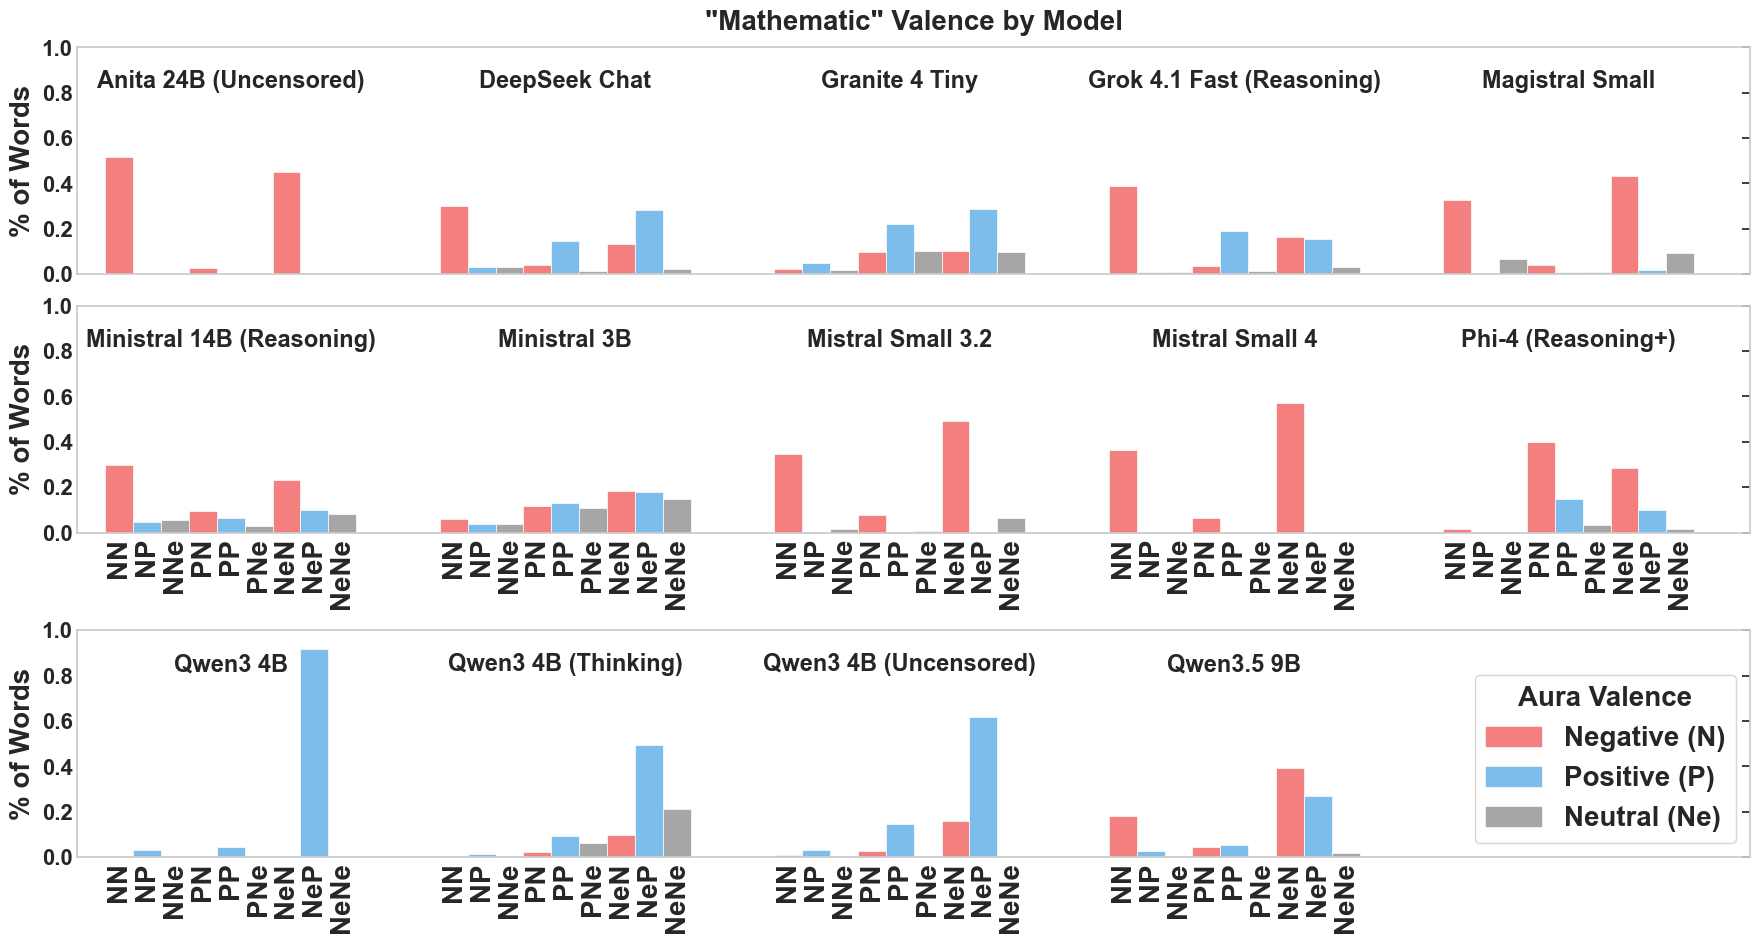

Generating plot for: science


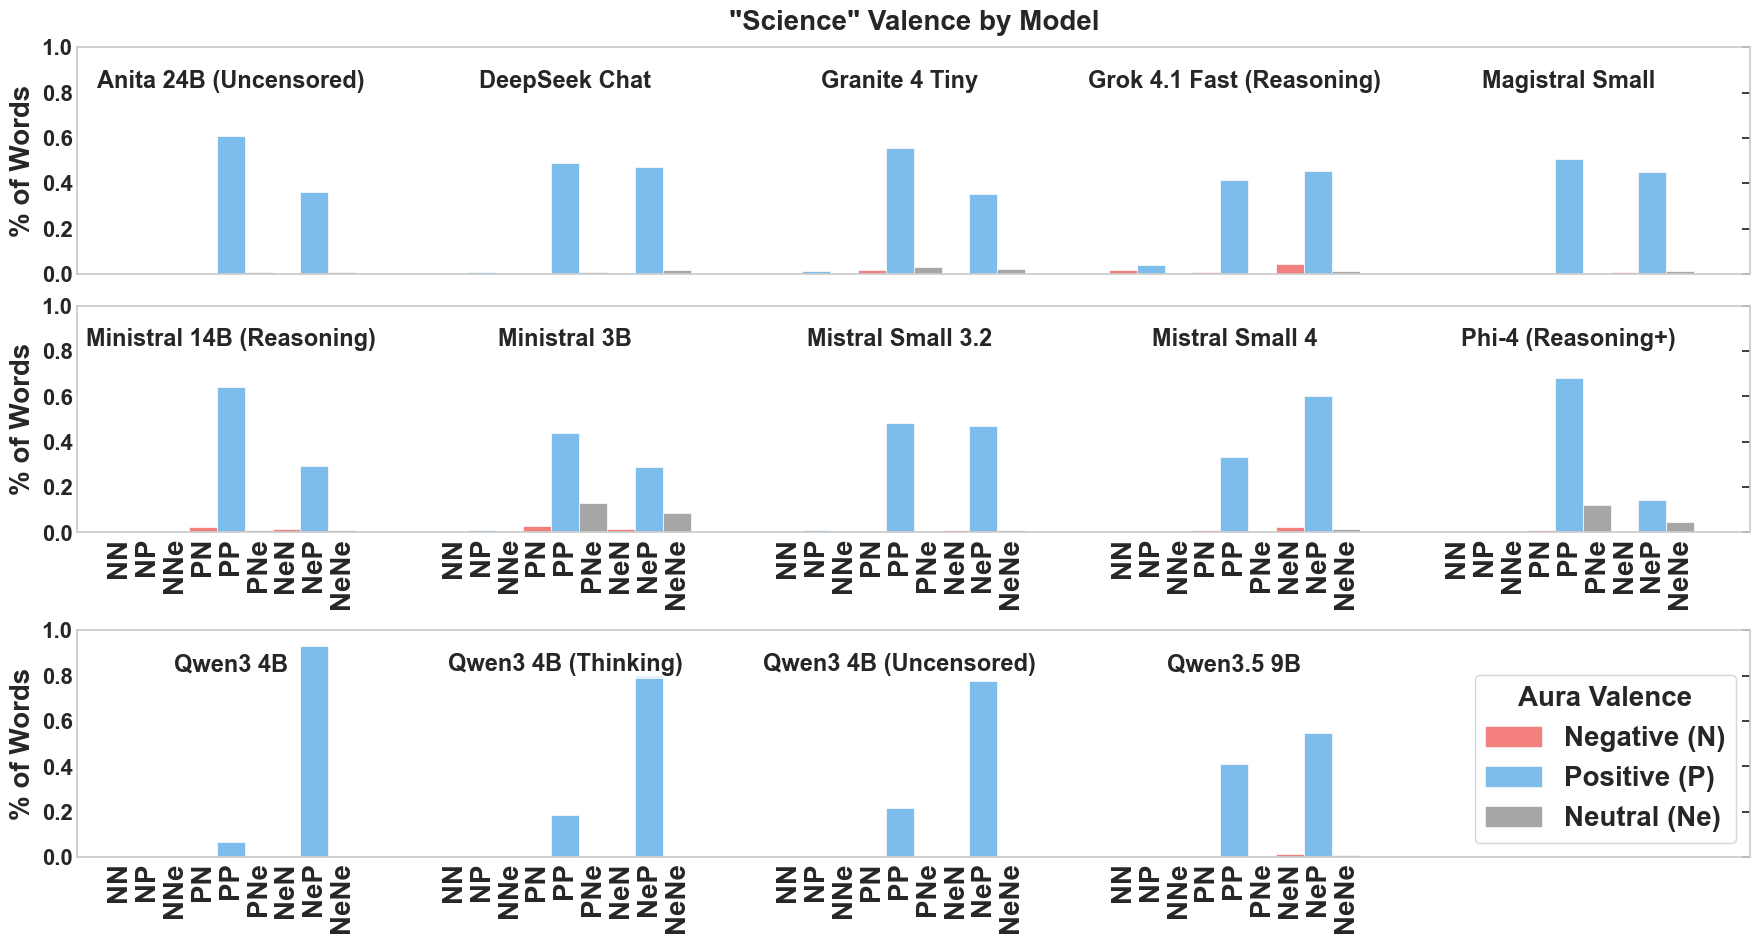

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches 
import math

# Set global base font size
plt.rcParams.update({
    'font.family': 'sans-serif',   # Add a specific font like 'Arial' here if needed
    'font.size': 20,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'legend.title_fontsize': 20
})

# 1. Load the datasets
# df_wide = aggregated_file
df_aura = pd.read_csv('/Users/luisaporzio/Projects/teachme-project/src/data_validation/aggregated/run_level_aura_valences.csv')

# Selected kw
subjects = ["mathematic", "science"]

# Clean up model names
df_aura['model_name_short'] = df_aura['model_name'].str.replace('compatible_dataset_', '').replace(FOLDER_NAME_MAPPING)
df_wide['model_name_short'] = df_wide['model_name'].str.replace('MANX_LLM_', '').replace(FOLDER_NAME_MAPPING)

# 2. Instance-Level Merge
merged = pd.merge(df_wide, df_aura, on=['model_name_short', 'cue_word', 'run_id'], how='inner')
merged = merged[merged["cue_word"].isin(subjects)]

# 3. Categorize Valences into N, P, Ne
def categorize_valence(val):
    if val > 0: return 'P'
    elif val < 0: return 'N'
    else: return 'Ne'

merged['kw_cat'] = merged['valence_cue_word'].apply(categorize_valence)
merged['aura_cat'] = merged['aura_net_valence'].apply(categorize_valence)

# Combine them into the 9 categories (e.g., 'N' + 'N' = 'NN')
merged['valence_pair'] = merged['kw_cat'] + merged['aura_cat']

# The exact 9 categories from the image in order
categories = ['NN', 'NP', 'NNe', 'PN', 'PP', 'PNe', 'NeN', 'NeP', 'NeNe']
colors = ['#f47f7f', '#7cbdec', '#a6a6a6'] * 3 

# 4. Define a plotting function for a single keyword
def plot_keyword_combinations(df, keyword, row_layout=[5, 5, 4]):
    df_kw = df[df['cue_word'] == keyword]
    
    proportions = df_kw.groupby('model_name_short')['valence_pair'].value_counts(normalize=True).unstack(fill_value=0)
    
    for cat in categories:
        if cat not in proportions.columns:
            proportions[cat] = 0
            
    proportions = proportions[categories]
    models = sorted(proportions.index.tolist())
    
    models_rows = []
    start_idx = 0
    for count in row_layout:
        end_idx = start_idx + count
        chunk = models[start_idx:end_idx]
        if chunk:  
            models_rows.append(chunk)
        start_idx = end_idx
        
    num_rows = len(models_rows)
    max_models_in_row = max(len(r) for r in models_rows)
    max_x_limit = max_models_in_row * (len(categories) + 3)
    
    fig, axes = plt.subplots(num_rows, 1, figsize=(18, 3.5 * num_rows), sharey=True)
    if num_rows == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        ax.grid(False)
        current_models = models_rows[i]
        
        category_ticks = []
        category_labels = []
        
        for j, model in enumerate(current_models):
            model_data = proportions.loc[model]
            
            x_start = j * (len(categories) + 3) 
            x_pos = np.arange(x_start, x_start + len(categories))
            
            for k, cat in enumerate(categories):
                ax.bar(x_pos[k], model_data[cat], width=1.0, color=colors[k], edgecolor='white', linewidth=0.5)
            
            category_ticks.extend(x_pos)
            category_labels.extend(categories)
            
            # Center the model tick under the 9 bars
            model_center = x_start + len(categories)/2 - 0.5
            
            # Place the model name inside the plot at the top of the group
            ax.text(model_center, 0.90, model, 
                    fontsize=17, fontweight='bold', ha='center', va='top',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
            
        # Perfect Alignment
        ax.set_xticks(category_ticks)
        
        if i == 0:
            # First row: No x-axis labels
            ax.set_xticklabels([]) 
        else:
            # Second and third row: Show x-axis labels
            ax.set_xticklabels(category_labels, fontsize=20, rotation=90, ha='center', va='top') 
            
        ax.tick_params(axis='x', which='major', length=0)
        
        ax.tick_params(axis='y', which='major', direction='in', right=True, labelsize=16)
        ax.set_ylabel('% of Words', fontsize=20, fontweight='bold') 
        ax.set_xlim(-1.5, max_x_limit - 1.5)
        
        # Enforce Y-limits so the inside text (y=0.90) stays consistently placed
        ax.set_ylim(0, 1.0)
        
        if i == 0:
            ax.text(0.5, 1.05, f'"{keyword.capitalize()}" Valence by Model', 
                    transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='center',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=3))

    legend_patches = [
        mpatches.Patch(color='#f47f7f', label='Negative (N)'),
        mpatches.Patch(color='#7cbdec', label='Positive (P)'),
        mpatches.Patch(color='#a6a6a6', label='Neutral (Ne)')
    ]
    
    leg = axes[-1].legend(
        handles=legend_patches, 
        loc='lower right', 
        title='Aura Valence', 
        prop={'size': 20, 'weight': 'bold'} 
    )
    leg.get_title().set_fontweight('bold') 
    leg.get_title().set_fontsize(20)       

    plt.tight_layout(h_pad=0.5)
    
    # --- MODIFIED: Mathematically exact 8mm spacing ---
    if num_rows > 1:
        fig.canvas.draw()  # Force layout calculation
        pos0 = axes[0].get_position()
        pos1 = axes[1].get_position()
        
        # Calculate exactly 8mm in inches (8mm / 25.4mm per inch)
        target_gap_inches = 8.0 / 25.4
        fig_height_inches = fig.get_figheight()
        
        # Convert target gap to relative figure coordinates (0 to 1)
        target_gap_rel = target_gap_inches / fig_height_inches
        
        # Measure current gap between bottom of row 0 and top of row 1
        current_bottom_0 = pos0.y0
        current_top_1 = pos1.y0 + pos1.height
        current_gap = current_bottom_0 - current_top_1
        
        # Calculate shift needed to make the gap exactly 8mm
        shift = current_gap - target_gap_rel
        axes[0].set_position([pos0.x0, pos0.y0 - shift, pos0.width, pos0.height])

    # plt.savefig(f"./visualizations/{keyword}_Aura_comparison.svg", dpi=300, format="svg")
    plt.show()

# 5. Generate the plots for both keywords
for kw in subjects:
    print(f"Generating plot for: {kw}")
    plot_keyword_combinations(merged, kw, row_layout=[5, 5, 4])